Classiying Resistance by Origin

Here is a pie chart showing the distribution of antibiotic resistance occurrences grouped by Origin. It summarizes how frequently resistant ("R") results appear across all antibiotics for each origin in the dataset.

In [3]:
pip install matplotlib

  Using cached matplotlib-3.10.7-cp314-cp314-win_amd64.whl.metadata (11 kB)
  Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.60.1-cp314-cp314-win_amd64.whl.metadata (114 kB)
  Using cached kiwisolver-1.4.9-cp314-cp314-win_amd64.whl.metadata (6.4 kB)
  Using cached pillow-11.3.0-cp314-cp314-win_amd64.whl.metadata (9.2 kB)
  Using cached pyparsing-3.2.5-py3-none-any.whl.metadata (5.0 kB)
Using cached matplotlib-3.10.7-cp314-cp314-win_amd64.whl (8.3 MB)
Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl (232 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.60.1-cp314-cp314-win_amd64.whl (2.3 MB)
Using cached kiwisolver-1.4.9-cp314-cp314-win_amd64.whl (75 kB)
Using cached pillow-11.3.0-cp314-cp314-win_amd64.whl (7.1 MB)
Using cached pyparsing-3.2.5-py3-none-any.whl (113 kB)

   ---------------------------------------- 0/7 [pyparsing]
   -

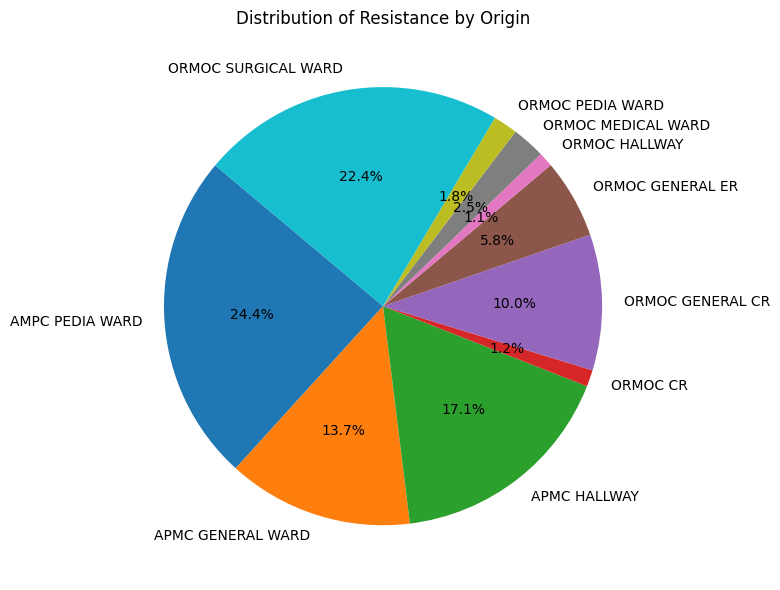

In [5]:
import matplotlib.pyplot as plt
import pandas as pd

# Clean column names by stripping whitespaces and newlines
df = pd.read_excel(r'C:\Users\User\Documents\SPVM 2025\AMR_merged_all_samples_ordered.xlsx')
df.columns = df.columns.str.strip().str.replace('\n', ' ').str.replace('\r', '')

# Filter only resistance data: those columns with R/S values
resistance_cols = df.columns[4:]  # first 4 columns are Sample_ID, Origin, Bacteria, Unnamed
resistance_data = df[resistance_cols]

# Create a mask for resistant values
resistant_mask = resistance_data == 'R'

# Add Origin to the resistance mask for grouping
resistant_mask['Origin'] = df['Origin']

# Sum resistant counts per origin
resistance_by_origin = resistant_mask.groupby('Origin').sum().sum(axis=1)

# Plotting
plt.figure(figsize=(10, 6))
resistance_by_origin.plot(kind='pie', autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Resistance by Origin')
plt.ylabel('')
plt.tight_layout()
plt.show()


In [6]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

# Load the dataset
d 
df = df.dropna(axis=1, how='all').dropna(axis=0, how='all')

# Define resistance columns and convert R/S to binary
resistance_columns = df.columns[4:]
origins = df['Origin'].unique()

def convert_rs(val):
    if val == 'R': return 1
    if val == 'S': return 0
    return None

# Compute metrics
summary = []
for origin in origins:
    subset = df[df['Origin'] == origin]
    for abx in resistance_columns:
        values = subset[abx].map(convert_rs).dropna()
        if values.nunique() == 2:  # Ensure both 0 and 1 exist
            y_true = values.astype(int)
            y_pred = [1] * len(y_true)  # Naive model predicts all Resistant
            precision = precision_score(y_true, y_pred, zero_division=0)
            recall = recall_score(y_true, y_pred, zero_division=0)
            f1 = f1_score(y_true, y_pred, zero_division=0)
            summary.append({
                'Origin': origin,
                'Antibiotic': abx,
                'Precision': precision,
                'Recall': recall,
                'F1 Score': f1
            })

# Create summary DataFrame
summary_df = pd.DataFrame(summary)
summary_df

ModuleNotFoundError: No module named 'sklearn'

C:\Users\User\AppData\Local\Temp\ipykernel_3148\1123283203.py:16: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_encoded = X.replace({'R': 1, 'S': 0, 'I': 0.5, '+': 1, '-': 0}).fillna(-1).astype(float)
C:\Users\User\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\User\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted s

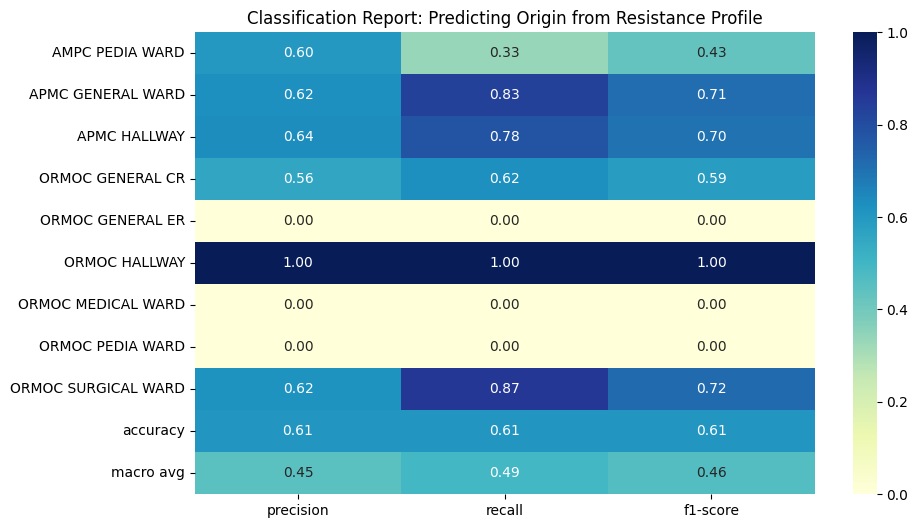

In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load dataset
df = df.loc[:, ~df.columns.str.contains('^Unnamed|nan', na=False)].dropna(axis=1, how='all')

# 2. Extract features and target
X = df.drop(columns=["Sample_ID", "Origin", "Bacteria"])
y = df["Origin"]

# 3. Encode resistance: R=1, S=0, I=0.5, +=1, -=0, NaN=-1
X_encoded = X.replace({'R': 1, 'S': 0, 'I': 0.5, '+': 1, '-': 0}).fillna(-1).astype(float)

# 4. Split data
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, stratify=y, random_state=42)

# 5. Train Random Forest model
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# 6. Evaluate model
y_pred = clf.predict(X_test)
report = pd.DataFrame(classification_report(y_test, y_pred, output_dict=True)).transpose()

# 7. Visualize results
plt.figure(figsize=(10, 6))
sns.heatmap(report.iloc[:-1, :-1], annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Classification Report: Predicting Origin from Resistance Profile")
plt.show()


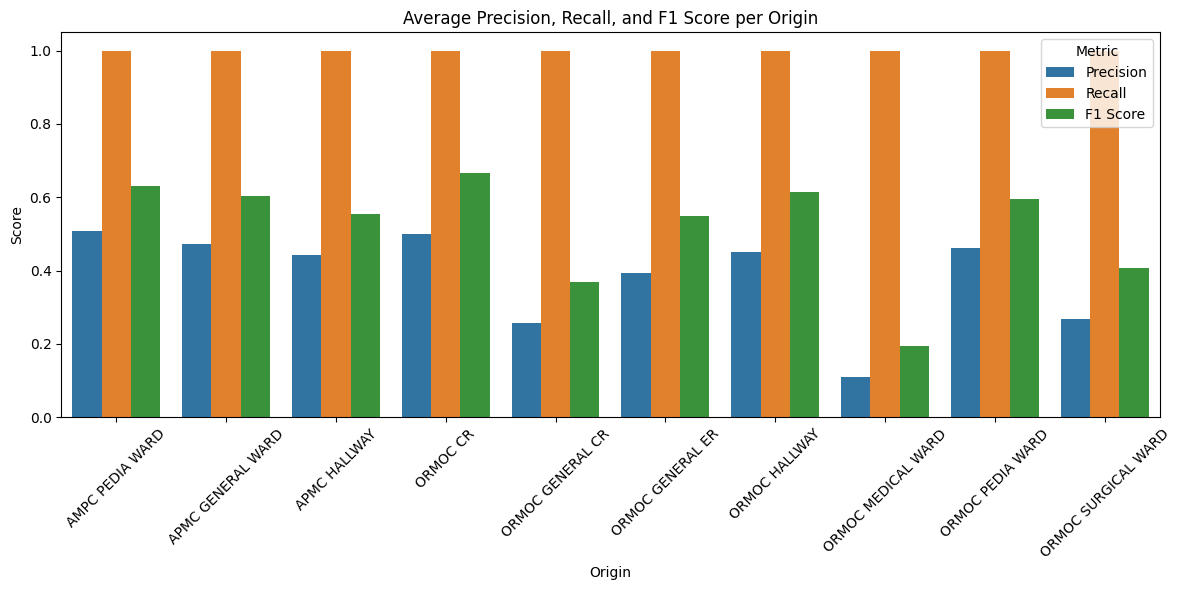

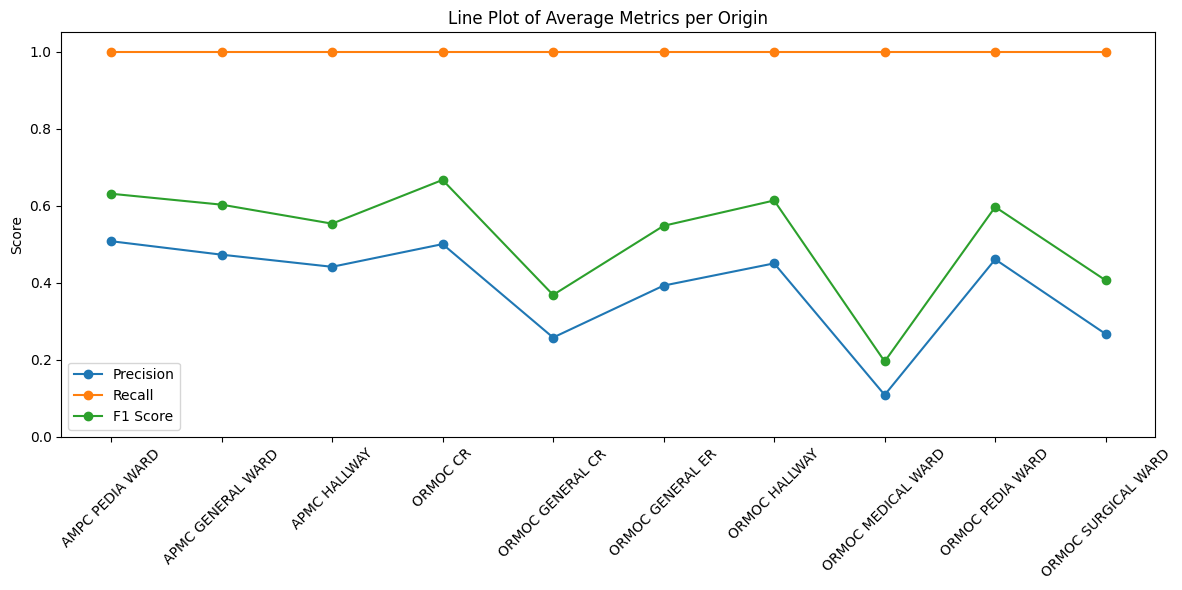

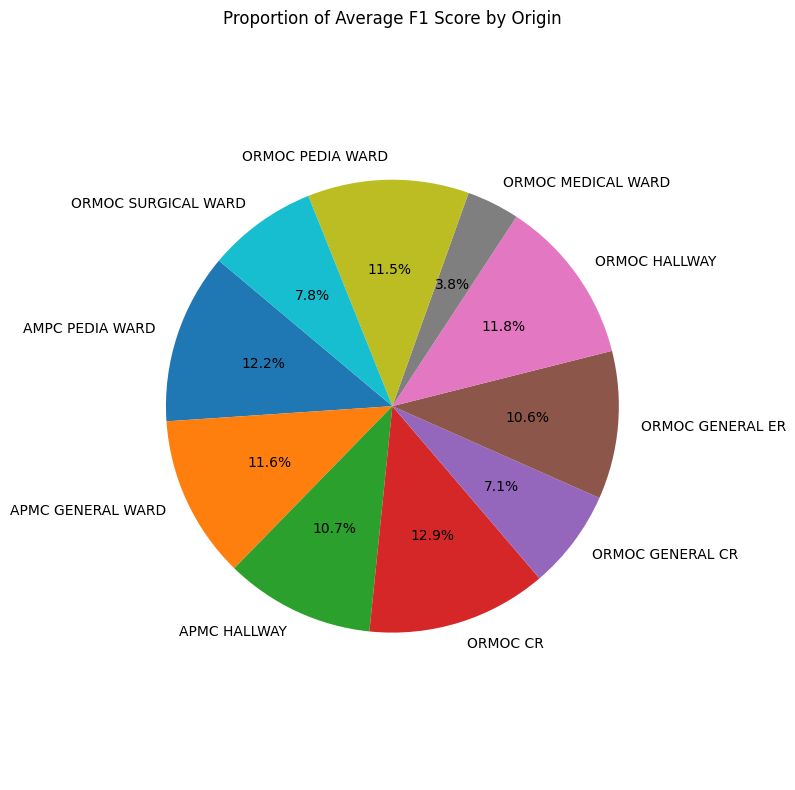

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_score, recall_score, f1_score

# Load and clean the data
df = pd.read_excel(r'C:\Users\User\Documents\SPVM 2025\AMR_merged_all_samples_ordered.xlsx')
df = df.dropna(axis=1, how='all').dropna(axis=0, how='all')

# Identify resistance columns
resistance_columns = df.columns[4:]  # Adjust index if needed
origins = df['Origin'].dropna().unique()

# Helper to convert R/S to binary
def convert_rs(val):
    if val == 'R': return 1
    if val == 'S': return 0
    return None

# Compute metrics per Origin and Antibiotic
summary = []
for origin in origins:
    subset = df[df['Origin'] == origin]
    for abx in resistance_columns:
        values = subset[abx].map(convert_rs).dropna()
        if values.nunique() == 2:
            y_true = values.astype(int)
            y_pred = [1] * len(y_true)
            precision = precision_score(y_true, y_pred, zero_division=0)
            recall = recall_score(y_true, y_pred, zero_division=0)
            f1 = f1_score(y_true, y_pred, zero_division=0)
            summary.append({
                'Origin': origin,
                'Antibiotic': abx,
                'Precision': precision,
                'Recall': recall,
                'F1 Score': f1
            })

# Convert to DataFrame
summary_df = pd.DataFrame(summary)

# --- Visualization ---
# Group by Origin and calculate average metrics
origin_avg = summary_df.groupby('Origin')[['Precision', 'Recall', 'F1 Score']].mean().reset_index()

# Bar Chart
plt.figure(figsize=(12, 6))
sns.barplot(data=origin_avg.melt(id_vars='Origin', var_name='Metric', value_name='Score'),
            x='Origin', y='Score', hue='Metric')
plt.title('Average Precision, Recall, and F1 Score per Origin')
plt.xticks(rotation=45)
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

# Line Chart
plt.figure(figsize=(12, 6))
for metric in ['Precision', 'Recall', 'F1 Score']:
    plt.plot(origin_avg['Origin'], origin_avg[metric], marker='o', label=metric)
plt.title('Line Plot of Average Metrics per Origin')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.show()

# Pie Chart for F1 Score
plt.figure(figsize=(8, 8))
plt.pie(origin_avg['F1 Score'], labels=origin_avg['Origin'], autopct='%1.1f%%', startangle=140)
plt.title('Proportion of Average F1 Score by Origin')
plt.axis('equal')
plt.tight_layout()
plt.show()


Below is a summary of all sample origins, including the number of tests conducted and the corresponding resistance to antibiotics.

AMPC PEDIA WARD SUMMARY

In [15]:
import pandas as pd

# Load the dataset
df = pd.read_excel(r'C:\Users\User\Documents\SPVM 2025\AMR_merged_all_samples_ordered.xlsx')

# Standardize column names
df.columns = df.columns.str.strip().str.replace('\n', ' ').str.replace(r'\s+', ' ', regex=True)

# Filter hallway rows (adjust the filter based on actual content!)
df_hallway = df[df['Origin'].str.contains("PEDIA WARD", case=False)]

# Identify antibiotic-related columns
non_antibiotic_cols = ['Sample_ID', 'Origin', 'Bacteria']
antibiotic_cols_all = [
    col for col in df_hallway.columns
    if col not in non_antibiotic_cols and not col.lower().startswith('unnamed') and not col.lower().startswith('nan')
]

# Encode resistance: R = 1, others = 0
encoded_antibiotics = df_hallway[antibiotic_cols_all].apply(lambda col: col.map(lambda x: 1 if x == 'R' else 0))

# Combine metadata with encoded resistance
df_encoded = pd.concat([df_hallway[non_antibiotic_cols].reset_index(drop=True), encoded_antibiotics.reset_index(drop=True)], axis=1)

# Count isolates per bacteria
bacteria_counts = df_encoded.groupby('Bacteria').agg({'Sample_ID': 'count'}).rename(columns={'Sample_ID': 'Isolates Count'})

# Sum resistance counts per antibiotic
resistance_summary_all = df_encoded.groupby('Bacteria')[antibiotic_cols_all].sum()

# Merge into final summary
pediaward_full_summary = pd.concat([bacteria_counts, resistance_summary_all], axis=1).reset_index()

# Display or save
print(pediaward_full_summary)

                          Bacteria  Isolates Count  +Amoxicillin  \
0  Acinetobacter baumannii complex               2             0   
1     Enterobacter cloacae complex              20             0   
2            Enterococcus faecalis               2             0   
3             Enterococcus faecium               1             0   
4                 Escherichia coli               1             0   
5  Klebsiella pneumoniae ssp pneum              14             0   
6           Pseudomonas aeruginosa               4             0   
7                   Salmonella spp               1             0   
8            Staphylococcus aureus               3             3   

   +Azithromycin  +Cefotaxime  +Ceftaroline  +Ceftazidime  \
0              0            0             0             0   
1              0            0             0             0   
2              0            2             0             2   
3              0            1             0             1   
4             

C:\Users\User\AppData\Local\Temp\ipykernel_3148\1320640496.py:13: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  encoded_antibiotics = df_pedia[antibiotic_cols_all].applymap(lambda x: 1 if x == 'R' else 0)


<Figure size 1400x800 with 0 Axes>

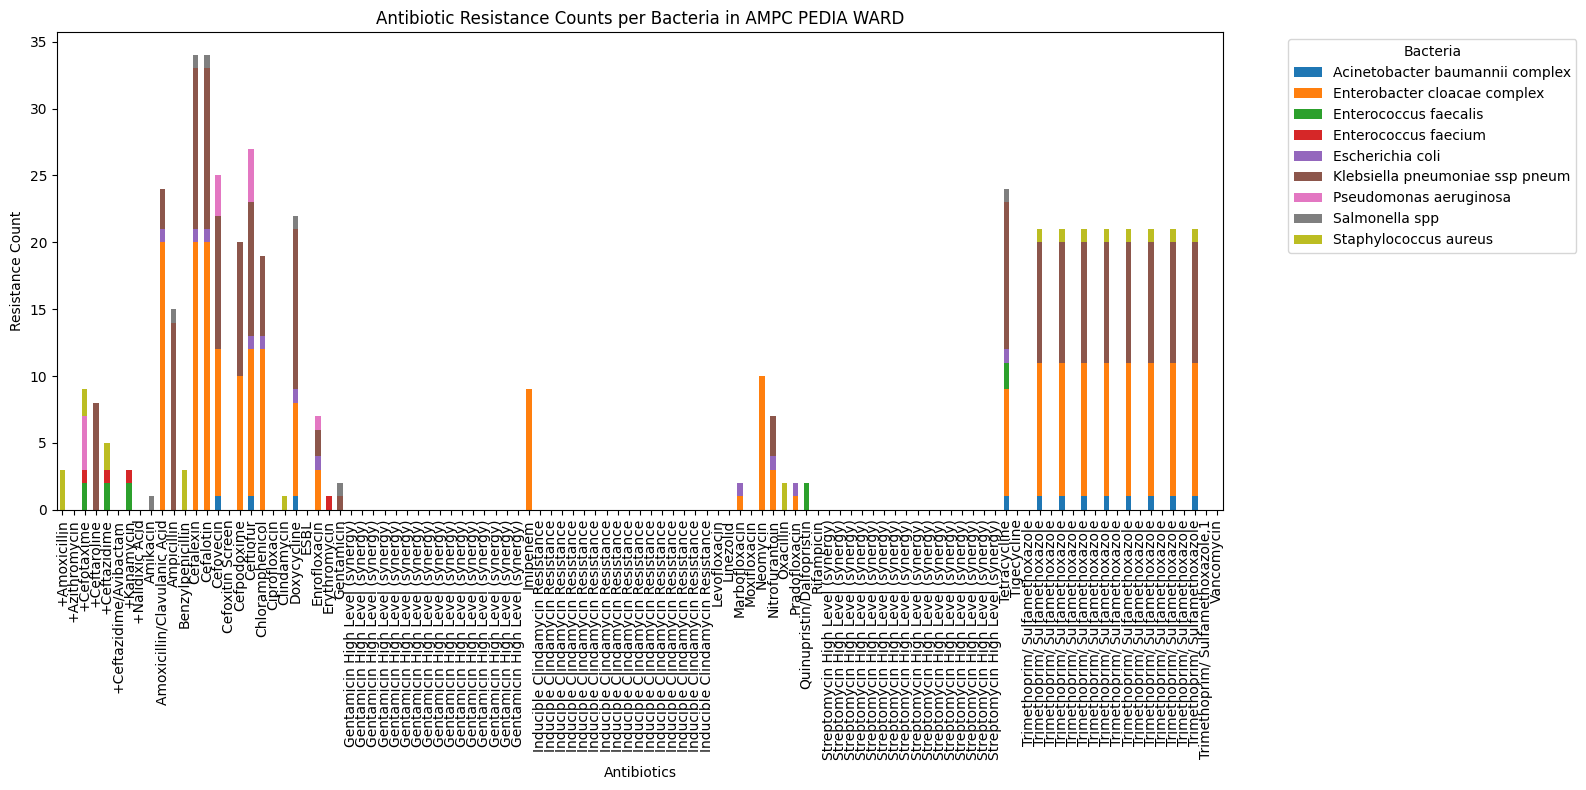

In [16]:
# Re-using the data previously loaded and cleaned for consistency
# Filter rows for "AMPC PEDIA WARD"
df_pedia = df[df['Origin'].str.contains("PEDIA WARD", case=False, na=False)]

# Identify antibiotic-related columns
non_antibiotic_cols = ['Sample_ID', 'Origin', 'Bacteria']
antibiotic_cols_all = [
    col for col in df_pedia.columns
    if col not in non_antibiotic_cols and not col.lower().startswith('unnamed') and not col.lower().startswith('nan')
]

# Encode resistance: R = 1, others = 0
encoded_antibiotics = df_pedia[antibiotic_cols_all].applymap(lambda x: 1 if x == 'R' else 0)

# Combine metadata with encoded resistance
df_encoded = pd.concat([df_pedia[non_antibiotic_cols].reset_index(drop=True), encoded_antibiotics.reset_index(drop=True)], axis=1)

# Count isolates per bacteria
bacteria_counts = df_encoded.groupby('Bacteria').agg({'Sample_ID': 'count'}).rename(columns={'Sample_ID': 'Isolates Count'})

# Sum resistance counts per antibiotic
resistance_summary_all = df_encoded.groupby('Bacteria')[antibiotic_cols_all].sum()

# Merge into final summary
pediaward_full_summary = pd.concat([bacteria_counts, resistance_summary_all], axis=1).reset_index()

# Plotting: Resistance count per bacteria (stacked bar chart)
plt.figure(figsize=(14, 8))
pediaward_full_summary.set_index('Bacteria')[antibiotic_cols_all].T.plot(kind='bar', stacked=True, figsize=(16, 8))
plt.title('Antibiotic Resistance Counts per Bacteria in AMPC PEDIA WARD')
plt.xlabel('Antibiotics')
plt.ylabel('Resistance Count')
plt.legend(title='Bacteria', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

AMPC HALLWAY SUMMARY

In [17]:
import pandas as pd

# Load the dataset
df = pd.read_excel(r'C:\Users\User\Documents\SPVM 2025\AMR_merged_all_samples_ordered.xlsx')

# Standardize column names
df.columns = df.columns.str.strip().str.replace('\n', ' ').str.replace(r'\s+', ' ', regex=True)

# Filter hallway rows (adjust the filter based on actual content!)
df_hallway = df[df['Origin'].str.contains("HALLWAY", case=False)]

# Identify antibiotic-related columns
non_antibiotic_cols = ['Sample_ID', 'Origin', 'Bacteria']
antibiotic_cols_all = [
    col for col in df_hallway.columns
    if col not in non_antibiotic_cols and not col.lower().startswith('unnamed') and not col.lower().startswith('nan')
]

# Encode resistance: R = 1, others = 0
encoded_antibiotics = df_hallway[antibiotic_cols_all].apply(lambda col: col.map(lambda x: 1 if x == 'R' else 0))

# Combine metadata with encoded resistance
df_encoded = pd.concat([df_hallway[non_antibiotic_cols].reset_index(drop=True), encoded_antibiotics.reset_index(drop=True)], axis=1)

# Count isolates per bacteria
bacteria_counts = df_encoded.groupby('Bacteria').agg({'Sample_ID': 'count'}).rename(columns={'Sample_ID': 'Isolates Count'})

# Sum resistance counts per antibiotic
resistance_summary_all = df_encoded.groupby('Bacteria')[antibiotic_cols_all].sum()

# Merge into final summary
hallway_full_summary = pd.concat([bacteria_counts, resistance_summary_all], axis=1).reset_index()

# Display or save
print(hallway_full_summary)

                          Bacteria  Isolates Count  +Amoxicillin  \
0     Enterobacter cloacae complex              29             0   
1            Enterococcus faecalis               1             0   
2             Enterococcus faecium               4             1   
3                 Escherichia coli               5             0   
4  Klebsiella pneumoniae ssp pneum               3             0   
5           Pseudomonas aeruginosa               2             0   
6            Staphylococcus aureus               3             2   
7      Staphylococcus haemolyticus               1             1   
8     Staphylococcus saprophyticus               1             1   

   +Azithromycin  +Cefotaxime  +Ceftaroline  +Ceftazidime  \
0              0            0             0             0   
1              0            1             0             1   
2              0            4             0             4   
3              0            0             0             0   
4             

C:\Users\User\AppData\Local\Temp\ipykernel_3148\403851278.py:13: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  encoded_antibiotics = df_pedia[antibiotic_cols_all].applymap(lambda x: 1 if x == 'R' else 0)


<Figure size 1400x800 with 0 Axes>

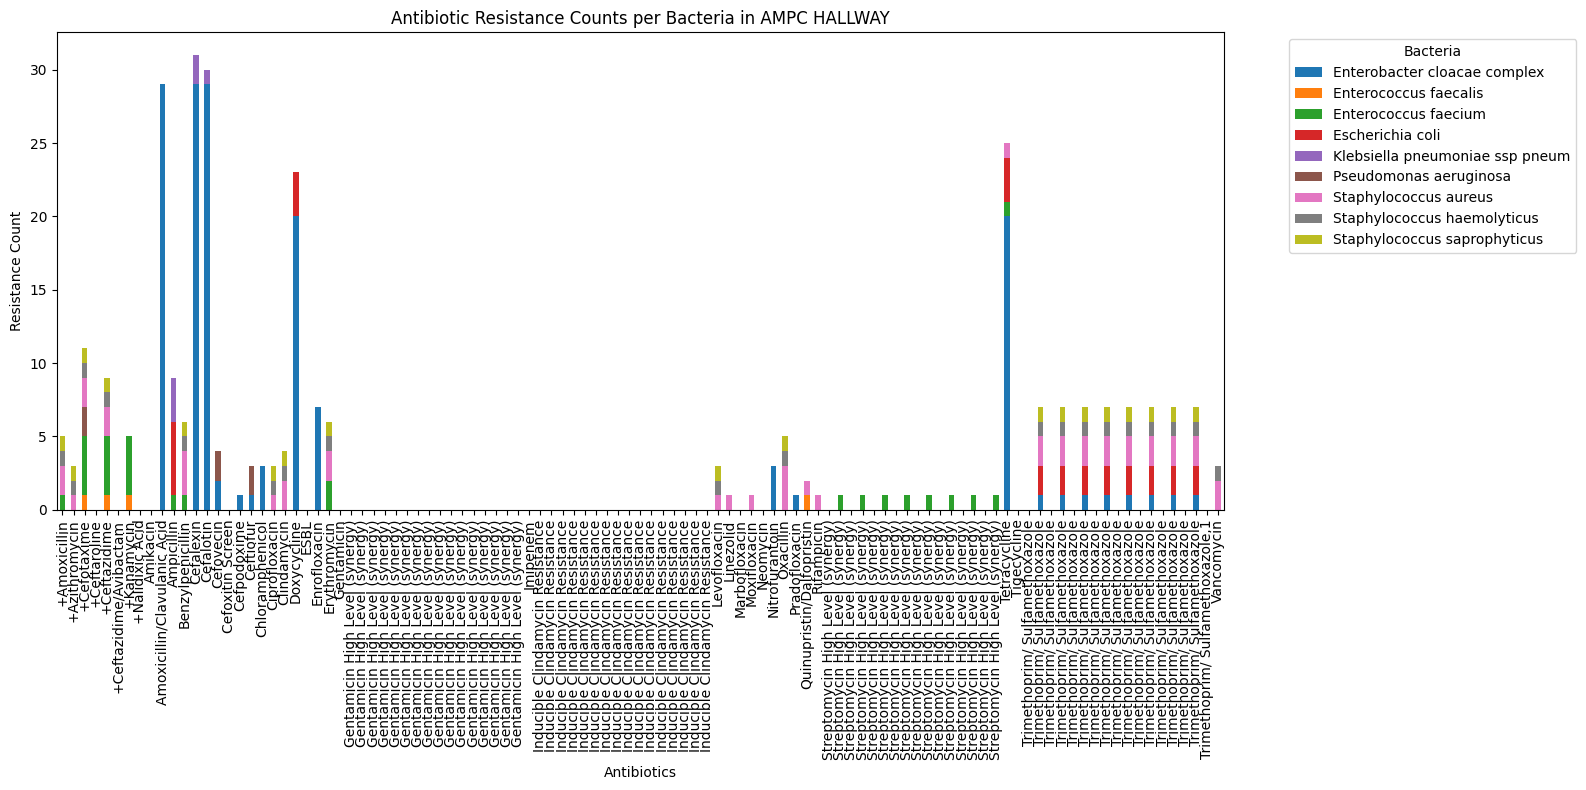

In [18]:
# Re-using the data previously loaded and cleaned for consistency
# Filter rows for "AMPC HALLWAY"
df_pedia = df[df['Origin'].str.contains("HALLWAY", case=False, na=False)]

# Identify antibiotic-related columns
non_antibiotic_cols = ['Sample_ID', 'Origin', 'Bacteria']
antibiotic_cols_all = [
    col for col in df_pedia.columns
    if col not in non_antibiotic_cols and not col.lower().startswith('unnamed') and not col.lower().startswith('nan')
]

# Encode resistance: R = 1, others = 0
encoded_antibiotics = df_pedia[antibiotic_cols_all].applymap(lambda x: 1 if x == 'R' else 0)

# Combine metadata with encoded resistance
df_encoded = pd.concat([df_pedia[non_antibiotic_cols].reset_index(drop=True), encoded_antibiotics.reset_index(drop=True)], axis=1)

# Count isolates per bacteria
bacteria_counts = df_encoded.groupby('Bacteria').agg({'Sample_ID': 'count'}).rename(columns={'Sample_ID': 'Isolates Count'})

# Sum resistance counts per antibiotic
resistance_summary_all = df_encoded.groupby('Bacteria')[antibiotic_cols_all].sum()

# Merge into final summary
hallway_full_summary = pd.concat([bacteria_counts, resistance_summary_all], axis=1).reset_index()

# Plotting: Resistance count per bacteria (stacked bar chart)
plt.figure(figsize=(14, 8))
hallway_full_summary.set_index('Bacteria')[antibiotic_cols_all].T.plot(kind='bar', stacked=True, figsize=(16, 8))
plt.title('Antibiotic Resistance Counts per Bacteria in AMPC HALLWAY')
plt.xlabel('Antibiotics')
plt.ylabel('Resistance Count')
plt.legend(title='Bacteria', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


AMPC GENERAL WARD SUMMARY

In [19]:
import pandas as pd


# Standardize column names
df.columns = df.columns.str.strip().str.replace('\n', ' ').str.replace(r'\s+', ' ', regex=True)

# Filter hallway rows (adjust the filter based on actual content!)
df_hallway = df[df['Origin'].str.contains("GENERAL WARD", case=False)]

# Identify antibiotic-related columns
non_antibiotic_cols = ['Sample_ID', 'Origin', 'Bacteria']
antibiotic_cols_all = [
    col for col in df_hallway.columns
    if col not in non_antibiotic_cols and not col.lower().startswith('unnamed') and not col.lower().startswith('nan')
]

# Encode resistance: R = 1, others = 0
encoded_antibiotics = df_hallway[antibiotic_cols_all].apply(lambda col: col.map(lambda x: 1 if x == 'R' else 0))

# Combine metadata with encoded resistance
df_encoded = pd.concat([df_hallway[non_antibiotic_cols].reset_index(drop=True), encoded_antibiotics.reset_index(drop=True)], axis=1)

# Count isolates per bacteria
bacteria_counts = df_encoded.groupby('Bacteria').agg({'Sample_ID': 'count'}).rename(columns={'Sample_ID': 'Isolates Count'})

# Sum resistance counts per antibiotic
resistance_summary_all = df_encoded.groupby('Bacteria')[antibiotic_cols_all].sum()

# Merge into final summary
generalward_full_summary = pd.concat([bacteria_counts, resistance_summary_all], axis=1).reset_index()

# Display or save
print(generalward_full_summary)

                          Bacteria  Isolates Count  +Amoxicillin  \
0  Acinetobacter baumannii complex               1             0   
1     Enterobacter cloacae complex              20             0   
2            Enterococcus faecalis               1             0   
3  Klebsiella pneumoniae ssp pneum               5             0   
4           Pseudomonas aeruginosa               5             0   

   +Azithromycin  +Cefotaxime  +Ceftaroline  +Ceftazidime  \
0              0            0             0             0   
1              0            0             0             0   
2              0            1             0             1   
3              0            0             0             0   
4              0            5             0             0   

   +Ceftazidime/Avibactam  +Kanamycin  +Nalidixic Acid  ...  \
0                       0           0                0  ...   
1                       0           0                0  ...   
2                       0          

C:\Users\User\AppData\Local\Temp\ipykernel_3148\327229443.py:13: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  encoded_antibiotics = df_pedia[antibiotic_cols_all].applymap(lambda x: 1 if x == 'R' else 0)


<Figure size 1400x800 with 0 Axes>

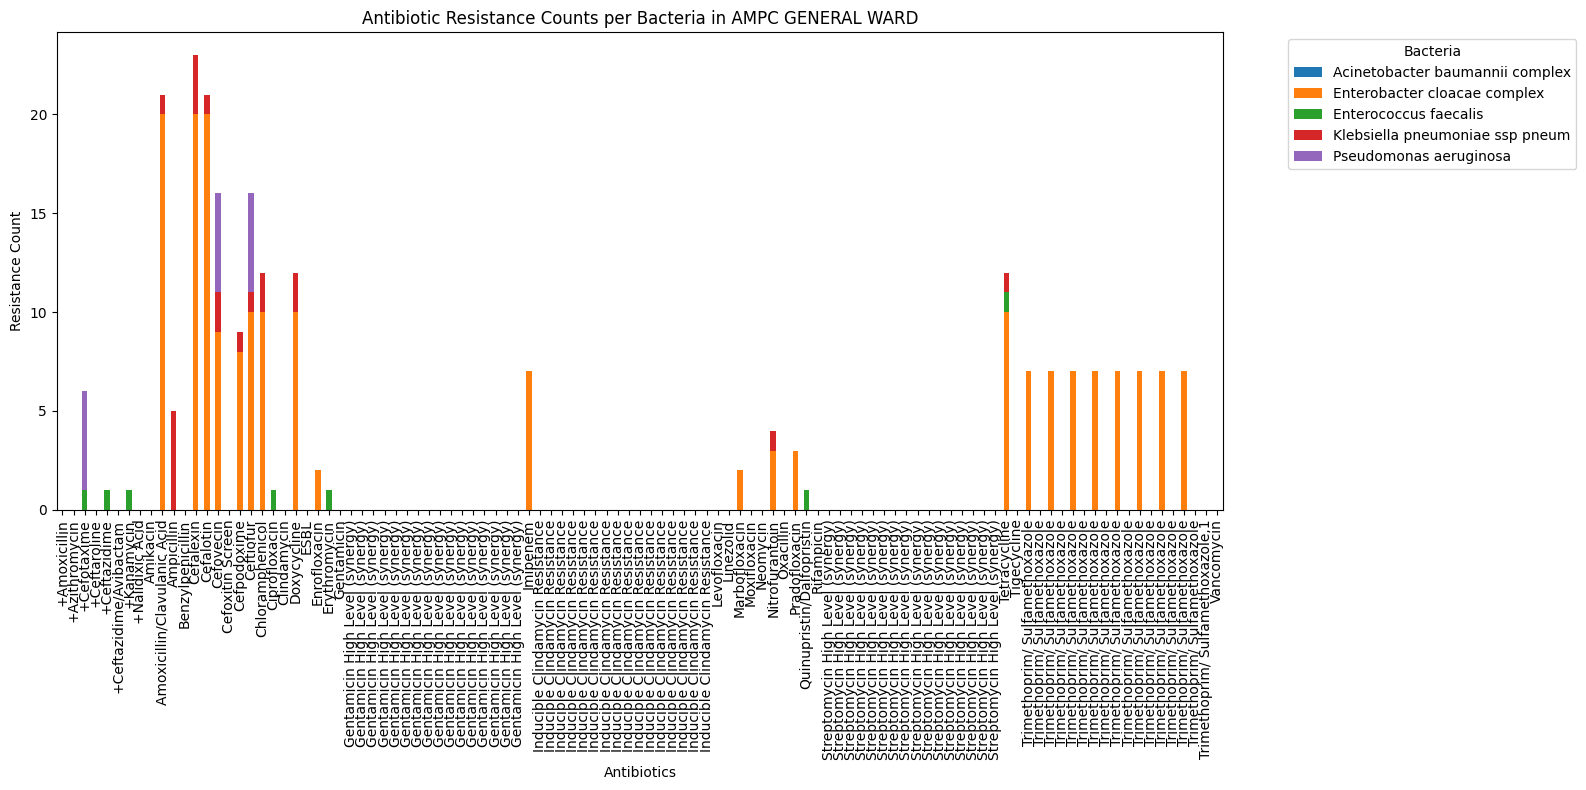

In [20]:
# Re-using the data previously loaded and cleaned for consistency
# Filter rows for "AMPC GENERAL WARD"
df_pedia = df[df['Origin'].str.contains("GENERAL WARD", case=False, na=False)]

# Identify antibiotic-related columns
non_antibiotic_cols = ['Sample_ID', 'Origin', 'Bacteria']
antibiotic_cols_all = [
    col for col in df_pedia.columns
    if col not in non_antibiotic_cols and not col.lower().startswith('unnamed') and not col.lower().startswith('nan')
]

# Encode resistance: R = 1, others = 0
encoded_antibiotics = df_pedia[antibiotic_cols_all].applymap(lambda x: 1 if x == 'R' else 0)

# Combine metadata with encoded resistance
df_encoded = pd.concat([df_pedia[non_antibiotic_cols].reset_index(drop=True), encoded_antibiotics.reset_index(drop=True)], axis=1)

# Count isolates per bacteria
bacteria_counts = df_encoded.groupby('Bacteria').agg({'Sample_ID': 'count'}).rename(columns={'Sample_ID': 'Isolates Count'})

# Sum resistance counts per antibiotic
resistance_summary_all = df_encoded.groupby('Bacteria')[antibiotic_cols_all].sum()

# Merge into final summary
generalward_full_summary = pd.concat([bacteria_counts, resistance_summary_all], axis=1).reset_index()

# Plotting: Resistance count per bacteria (stacked bar chart)
plt.figure(figsize=(14, 8))
generalward_full_summary.set_index('Bacteria')[antibiotic_cols_all].T.plot(kind='bar', stacked=True, figsize=(16, 8))
plt.title('Antibiotic Resistance Counts per Bacteria in AMPC GENERAL WARD')
plt.xlabel('Antibiotics')
plt.ylabel('Resistance Count')
plt.legend(title='Bacteria', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


ORMOC GENERAL CR SUMMARY

In [22]:
import pandas as pd

# Load the dataset
# Standardize column names
df.columns = df.columns.str.strip().str.replace('\n', ' ').str.replace(r'\s+', ' ', regex=True)

# Filter hallway rows (adjust the filter based on actual content!)
df_hallway = df[df['Origin'].str.contains("ORMOC GENERAL CR", case=False)]

# Identify antibiotic-related columns
non_antibiotic_cols = ['Sample_ID', 'Origin', 'Bacteria']
antibiotic_cols_all = [
    col for col in df_hallway.columns
    if col not in non_antibiotic_cols and not col.lower().startswith('unnamed') and not col.lower().startswith('nan')
]

# Encode resistance: R = 1, others = 0
encoded_antibiotics = df_hallway[antibiotic_cols_all].apply(lambda col: col.map(lambda x: 1 if x == 'R' else 0))

# Combine metadata with encoded resistance
df_encoded = pd.concat([df_hallway[non_antibiotic_cols].reset_index(drop=True), encoded_antibiotics.reset_index(drop=True)], axis=1)

# Count isolates per bacteria
bacteria_counts = df_encoded.groupby('Bacteria').agg({'Sample_ID': 'count'}).rename(columns={'Sample_ID': 'Isolates Count'})

# Sum resistance counts per antibiotic
resistance_summary_all = df_encoded.groupby('Bacteria')[antibiotic_cols_all].sum()

# Merge into final summary
ormocgeneralcr_full_summary = pd.concat([bacteria_counts, resistance_summary_all], axis=1).reset_index()

# Display or save
print(ormocgeneralcr_full_summary)

                          Bacteria  Isolates Count  +Amoxicillin  \
0  Acinetobacter baumannii complex               3             0   
1           Enterobacter aerogenes               1             0   
2     Enterobacter cloacae complex               4             0   
3             Enterococcus faecium               2             2   
4                 Escherichia coli               8             0   
5  Klebsiella pneumoniae ssp pneum              11             0   
6           Pseudomonas aeruginosa              10             0   
7                   Salmonella spp               1             0   

   +Azithromycin  +Cefotaxime  +Ceftaroline  +Ceftazidime  \
0              0            0             0             0   
1              0            0             0             0   
2              0            0             0             0   
3              0            2             0             2   
4              0            0             0             0   
5              0     

C:\Users\User\AppData\Local\Temp\ipykernel_3148\449042215.py:13: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  encoded_antibiotics = df_pedia[antibiotic_cols_all].applymap(lambda x: 1 if x == 'R' else 0)


<Figure size 1400x800 with 0 Axes>

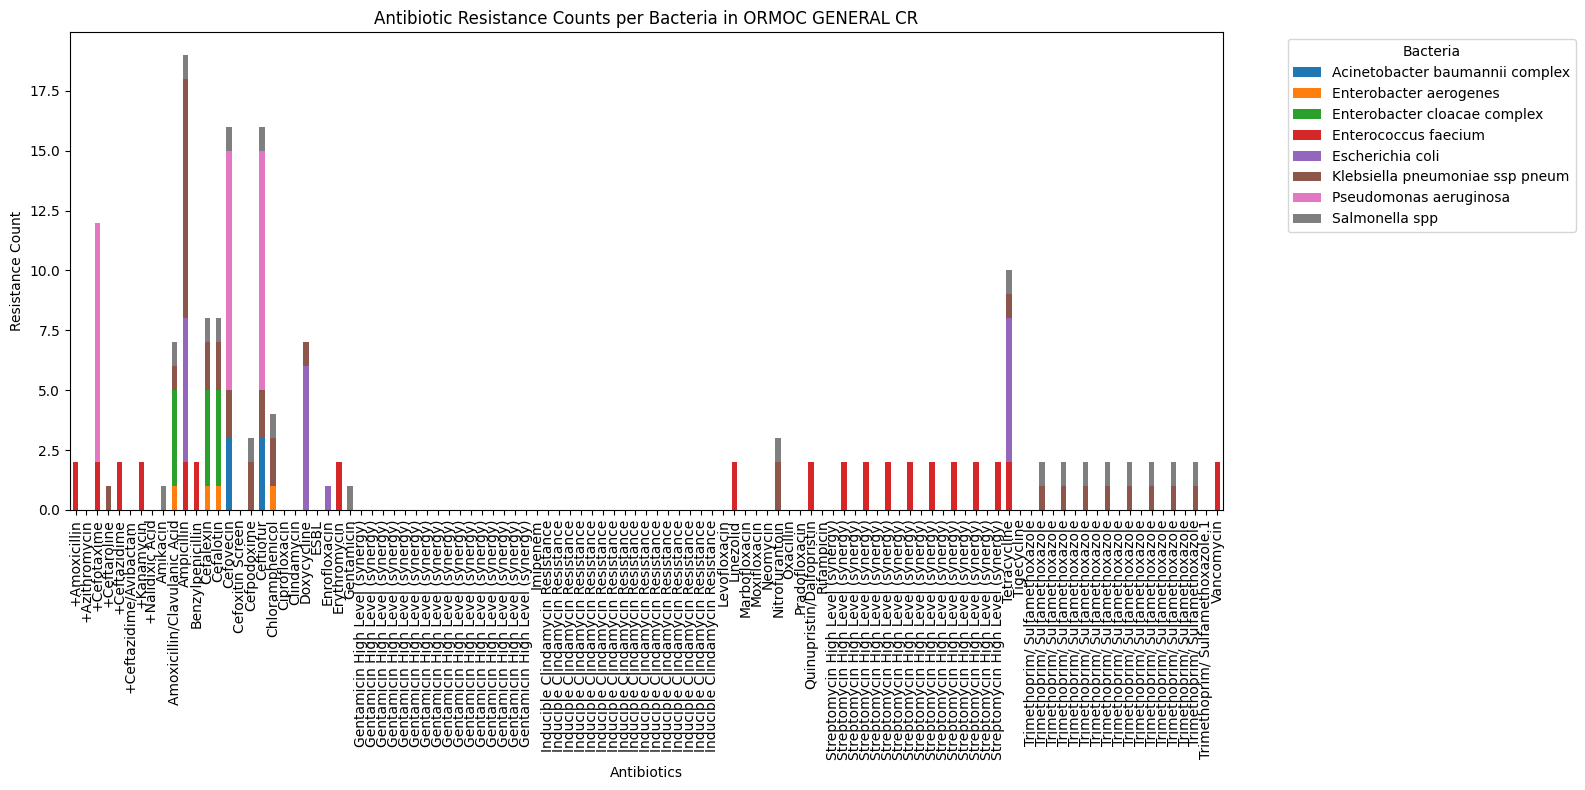

In [23]:
# Re-using the data previously loaded and cleaned for consistency
# Filter rows for "ORMOC GENERAL CR"
df_pedia = df[df['Origin'].str.contains("ORMOC GENERAL CR", case=False, na=False)]

# Identify antibiotic-related columns
non_antibiotic_cols = ['Sample_ID', 'Origin', 'Bacteria']
antibiotic_cols_all = [
    col for col in df_pedia.columns
    if col not in non_antibiotic_cols and not col.lower().startswith('unnamed') and not col.lower().startswith('nan')
]

# Encode resistance: R = 1, others = 0
encoded_antibiotics = df_pedia[antibiotic_cols_all].applymap(lambda x: 1 if x == 'R' else 0)

# Combine metadata with encoded resistance
df_encoded = pd.concat([df_pedia[non_antibiotic_cols].reset_index(drop=True), encoded_antibiotics.reset_index(drop=True)], axis=1)

# Count isolates per bacteria
bacteria_counts = df_encoded.groupby('Bacteria').agg({'Sample_ID': 'count'}).rename(columns={'Sample_ID': 'Isolates Count'})

# Sum resistance counts per antibiotic
resistance_summary_all = df_encoded.groupby('Bacteria')[antibiotic_cols_all].sum()

# Merge into final summary
ormocgeneralcr_full_summary = pd.concat([bacteria_counts, resistance_summary_all], axis=1).reset_index()

# Plotting: Resistance count per bacteria (stacked bar chart)
plt.figure(figsize=(14, 8))
ormocgeneralcr_full_summary.set_index('Bacteria')[antibiotic_cols_all].T.plot(kind='bar', stacked=True, figsize=(16, 8))
plt.title('Antibiotic Resistance Counts per Bacteria in ORMOC GENERAL CR')
plt.xlabel('Antibiotics')
plt.ylabel('Resistance Count')
plt.legend(title='Bacteria', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

ORMOC GENERAL ER

In [24]:
import pandas as pd

# Standardize column names
df.columns = df.columns.str.strip().str.replace('\n', ' ').str.replace(r'\s+', ' ', regex=True)

# Filter hallway rows (adjust the filter based on actual content!)
df_hallway = df[df['Origin'].str.contains("ORMOC GENERAL ER", case=False)]

# Identify antibiotic-related columns
non_antibiotic_cols = ['Sample_ID', 'Origin', 'Bacteria']
antibiotic_cols_all = [
    col for col in df_hallway.columns
    if col not in non_antibiotic_cols and not col.lower().startswith('unnamed') and not col.lower().startswith('nan')
]

# Encode resistance: R = 1, others = 0
encoded_antibiotics = df_hallway[antibiotic_cols_all].apply(lambda col: col.map(lambda x: 1 if x == 'R' else 0))

# Combine metadata with encoded resistance
df_encoded = pd.concat([df_hallway[non_antibiotic_cols].reset_index(drop=True), encoded_antibiotics.reset_index(drop=True)], axis=1)

# Count isolates per bacteria
bacteria_counts = df_encoded.groupby('Bacteria').agg({'Sample_ID': 'count'}).rename(columns={'Sample_ID': 'Isolates Count'})

# Sum resistance counts per antibiotic
resistance_summary_all = df_encoded.groupby('Bacteria')[antibiotic_cols_all].sum()

# Merge into final summary
ormocgeneraler_full_summary = pd.concat([bacteria_counts, resistance_summary_all], axis=1).reset_index()

# Display or save
print(ormocgeneraler_full_summary)

                          Bacteria  Isolates Count  +Amoxicillin  \
0  Acinetobacter baumannii complex               9             1   
1     Enterobacter cloacae complex              12             0   
2           Pseudomonas aeruginosa               1             0   
3            Staphylococcus aureus               1             1   

   +Azithromycin  +Cefotaxime  +Ceftaroline  +Ceftazidime  \
0              0            1             0             1   
1              0            0             0             0   
2              0            1             0             0   
3              0            1             0             1   

   +Ceftazidime/Avibactam  +Kanamycin  +Nalidixic Acid  ...  \
0                       0           0                0  ...   
1                       0           0                0  ...   
2                       0           0                0  ...   
3                       0           0                0  ...   

   Trimethoprim/ Sulfamethoxazole  Tr

C:\Users\User\AppData\Local\Temp\ipykernel_3148\1133718965.py:13: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  encoded_antibiotics = df_pedia[antibiotic_cols_all].applymap(lambda x: 1 if x == 'R' else 0)


<Figure size 1400x800 with 0 Axes>

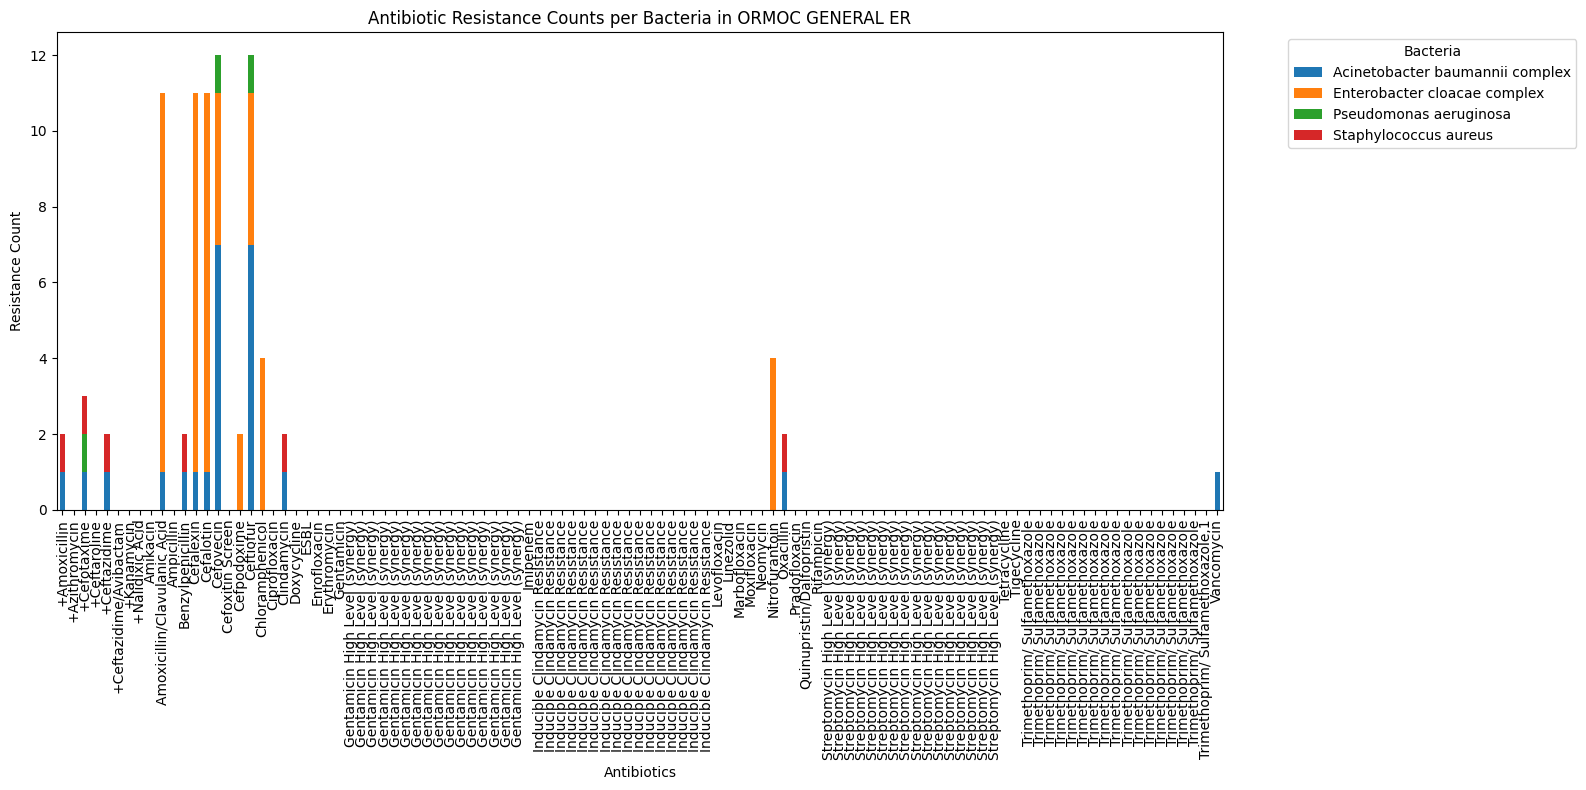

In [25]:
# Re-using the data previously loaded and cleaned for consistency
# Filter rows for "ORMOC GENERAL ER"
df_pedia = df[df['Origin'].str.contains("ORMOC GENERAL ER", case=False, na=False)]

# Identify antibiotic-related columns
non_antibiotic_cols = ['Sample_ID', 'Origin', 'Bacteria']
antibiotic_cols_all = [
    col for col in df_pedia.columns
    if col not in non_antibiotic_cols and not col.lower().startswith('unnamed') and not col.lower().startswith('nan')
]

# Encode resistance: R = 1, others = 0
encoded_antibiotics = df_pedia[antibiotic_cols_all].applymap(lambda x: 1 if x == 'R' else 0)

# Combine metadata with encoded resistance
df_encoded = pd.concat([df_pedia[non_antibiotic_cols].reset_index(drop=True), encoded_antibiotics.reset_index(drop=True)], axis=1)

# Count isolates per bacteria
bacteria_counts = df_encoded.groupby('Bacteria').agg({'Sample_ID': 'count'}).rename(columns={'Sample_ID': 'Isolates Count'})

# Sum resistance counts per antibiotic
resistance_summary_all = df_encoded.groupby('Bacteria')[antibiotic_cols_all].sum()

# Merge into final summary
ormocgeneraler_full_summary = pd.concat([bacteria_counts, resistance_summary_all], axis=1).reset_index()

# Plotting: Resistance count per bacteria (stacked bar chart)
plt.figure(figsize=(14, 8))
ormocgeneraler_full_summary.set_index('Bacteria')[antibiotic_cols_all].T.plot(kind='bar', stacked=True, figsize=(16, 8))
plt.title('Antibiotic Resistance Counts per Bacteria in ORMOC GENERAL ER')
plt.xlabel('Antibiotics')
plt.ylabel('Resistance Count')
plt.legend(title='Bacteria', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

ORMOC HALLWAY SUMMARY

In [26]:
import pandas as pd

# Standardize column names
df.columns = df.columns.str.strip().str.replace('\n', ' ').str.replace(r'\s+', ' ', regex=True)

# Filter hallway rows (adjust the filter based on actual content!)
df_hallway = df[df['Origin'].str.contains("ORMOC HALLWAY", case=False)]

# Identify antibiotic-related columns
non_antibiotic_cols = ['Sample_ID', 'Origin', 'Bacteria']
antibiotic_cols_all = [
    col for col in df_hallway.columns
    if col not in non_antibiotic_cols and not col.lower().startswith('unnamed') and not col.lower().startswith('nan')
]

# Encode resistance: R = 1, others = 0
encoded_antibiotics = df_hallway[antibiotic_cols_all].apply(lambda col: col.map(lambda x: 1 if x == 'R' else 0))

# Combine metadata with encoded resistance
df_encoded = pd.concat([df_hallway[non_antibiotic_cols].reset_index(drop=True), encoded_antibiotics.reset_index(drop=True)], axis=1)

# Count isolates per bacteria
bacteria_counts = df_encoded.groupby('Bacteria').agg({'Sample_ID': 'count'}).rename(columns={'Sample_ID': 'Isolates Count'})

# Sum resistance counts per antibiotic
resistance_summary_all = df_encoded.groupby('Bacteria')[antibiotic_cols_all].sum()

# Merge into final summary
ormochallway_full_summary = pd.concat([bacteria_counts, resistance_summary_all], axis=1).reset_index()

# Display or save
print(ormochallway_full_summary)

               Bacteria  Isolates Count  +Amoxicillin  +Azithromycin  \
0  Enterococcus faecium               2             0              0   
1      Escherichia coli               2             0              0   

   +Cefotaxime  +Ceftaroline  +Ceftazidime  +Ceftazidime/Avibactam  \
0            2             0             2                       0   
1            0             0             0                       0   

   +Kanamycin  +Nalidixic Acid  ...  Trimethoprim/ Sulfamethoxazole  \
0           2                0  ...                               0   
1           0                0  ...                               0   

   Trimethoprim/ Sulfamethoxazole  Trimethoprim/ Sulfamethoxazole  \
0                               0                               0   
1                               2                               0   

   Trimethoprim/ Sulfamethoxazole  Trimethoprim/ Sulfamethoxazole  \
0                               0                               0   
1           

C:\Users\User\AppData\Local\Temp\ipykernel_3148\1367906492.py:13: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  encoded_antibiotics = df_pedia[antibiotic_cols_all].applymap(lambda x: 1 if x == 'R' else 0)


<Figure size 1400x800 with 0 Axes>

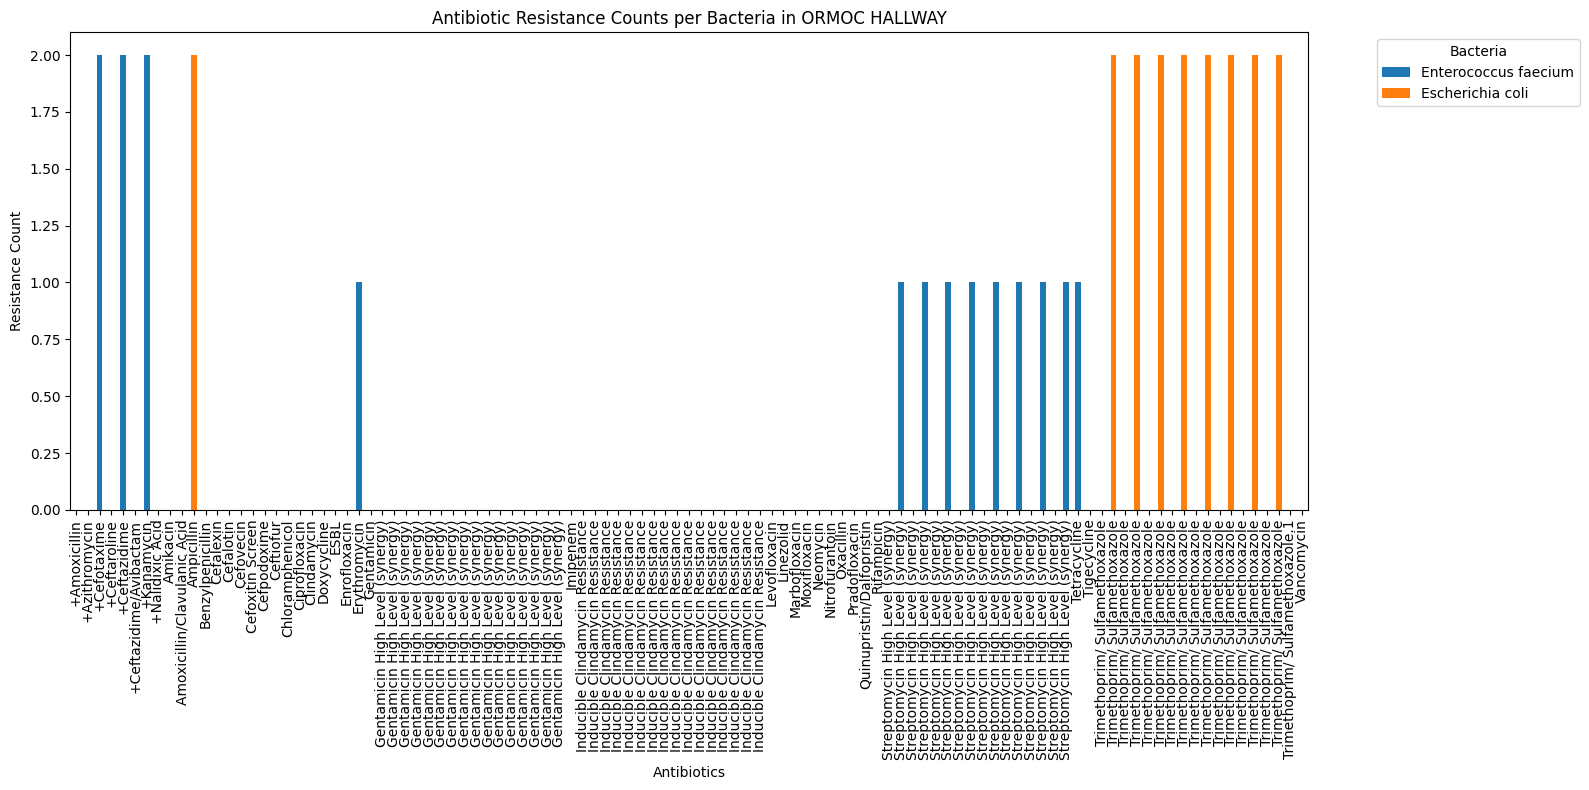

In [27]:
# Re-using the data previously loaded and cleaned for consistency
# Filter rows for "ORMOC HALLWAY"
df_pedia = df[df['Origin'].str.contains("ORMOC HALLWAY", case=False, na=False)]

# Identify antibiotic-related columns
non_antibiotic_cols = ['Sample_ID', 'Origin', 'Bacteria']
antibiotic_cols_all = [
    col for col in df_pedia.columns
    if col not in non_antibiotic_cols and not col.lower().startswith('unnamed') and not col.lower().startswith('nan')
]

# Encode resistance: R = 1, others = 0
encoded_antibiotics = df_pedia[antibiotic_cols_all].applymap(lambda x: 1 if x == 'R' else 0)

# Combine metadata with encoded resistance
df_encoded = pd.concat([df_pedia[non_antibiotic_cols].reset_index(drop=True), encoded_antibiotics.reset_index(drop=True)], axis=1)

# Count isolates per bacteria
bacteria_counts = df_encoded.groupby('Bacteria').agg({'Sample_ID': 'count'}).rename(columns={'Sample_ID': 'Isolates Count'})

# Sum resistance counts per antibiotic
resistance_summary_all = df_encoded.groupby('Bacteria')[antibiotic_cols_all].sum()

# Merge into final summary
ormochallway_full_summary = pd.concat([bacteria_counts, resistance_summary_all], axis=1).reset_index()

# Plotting: Resistance count per bacteria (stacked bar chart)
plt.figure(figsize=(14, 8))
ormochallway_full_summary.set_index('Bacteria')[antibiotic_cols_all].T.plot(kind='bar', stacked=True, figsize=(16, 8))
plt.title('Antibiotic Resistance Counts per Bacteria in ORMOC HALLWAY')
plt.xlabel('Antibiotics')
plt.ylabel('Resistance Count')
plt.legend(title='Bacteria', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


ORMOC MEDICAL WARD SUMMARY

In [28]:
import pandas as pd

# Standardize column names
df.columns = df.columns.str.strip().str.replace('\n', ' ').str.replace(r'\s+', ' ', regex=True)

# Filter hallway rows (adjust the filter based on actual content!)
df_hallway = df[df['Origin'].str.contains("ORMOC MEDICAL WARD", case=False)]

# Identify antibiotic-related columns
non_antibiotic_cols = ['Sample_ID', 'Origin', 'Bacteria']
antibiotic_cols_all = [
    col for col in df_hallway.columns
    if col not in non_antibiotic_cols and not col.lower().startswith('unnamed') and not col.lower().startswith('nan')
]

# Encode resistance: R = 1, others = 0
encoded_antibiotics = df_hallway[antibiotic_cols_all].apply(lambda col: col.map(lambda x: 1 if x == 'R' else 0))

# Combine metadata with encoded resistance
df_encoded = pd.concat([df_hallway[non_antibiotic_cols].reset_index(drop=True), encoded_antibiotics.reset_index(drop=True)], axis=1)

# Count isolates per bacteria
bacteria_counts = df_encoded.groupby('Bacteria').agg({'Sample_ID': 'count'}).rename(columns={'Sample_ID': 'Isolates Count'})

# Sum resistance counts per antibiotic
resistance_summary_all = df_encoded.groupby('Bacteria')[antibiotic_cols_all].sum()

# Merge into final summary
ormocmedicalward_full_summary = pd.concat([bacteria_counts, resistance_summary_all], axis=1).reset_index()

# Display or save
print(generalward_full_summary)

                          Bacteria  Isolates Count  +Amoxicillin  \
0  Acinetobacter baumannii complex               1             0   
1     Enterobacter cloacae complex              20             0   
2            Enterococcus faecalis               1             0   
3  Klebsiella pneumoniae ssp pneum               5             0   
4           Pseudomonas aeruginosa               5             0   

   +Azithromycin  +Cefotaxime  +Ceftaroline  +Ceftazidime  \
0              0            0             0             0   
1              0            0             0             0   
2              0            1             0             1   
3              0            0             0             0   
4              0            5             0             0   

   +Ceftazidime/Avibactam  +Kanamycin  +Nalidixic Acid  ...  \
0                       0           0                0  ...   
1                       0           0                0  ...   
2                       0          

C:\Users\User\AppData\Local\Temp\ipykernel_3148\1721370593.py:13: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  encoded_antibiotics = df_pedia[antibiotic_cols_all].applymap(lambda x: 1 if x == 'R' else 0)


<Figure size 1400x800 with 0 Axes>

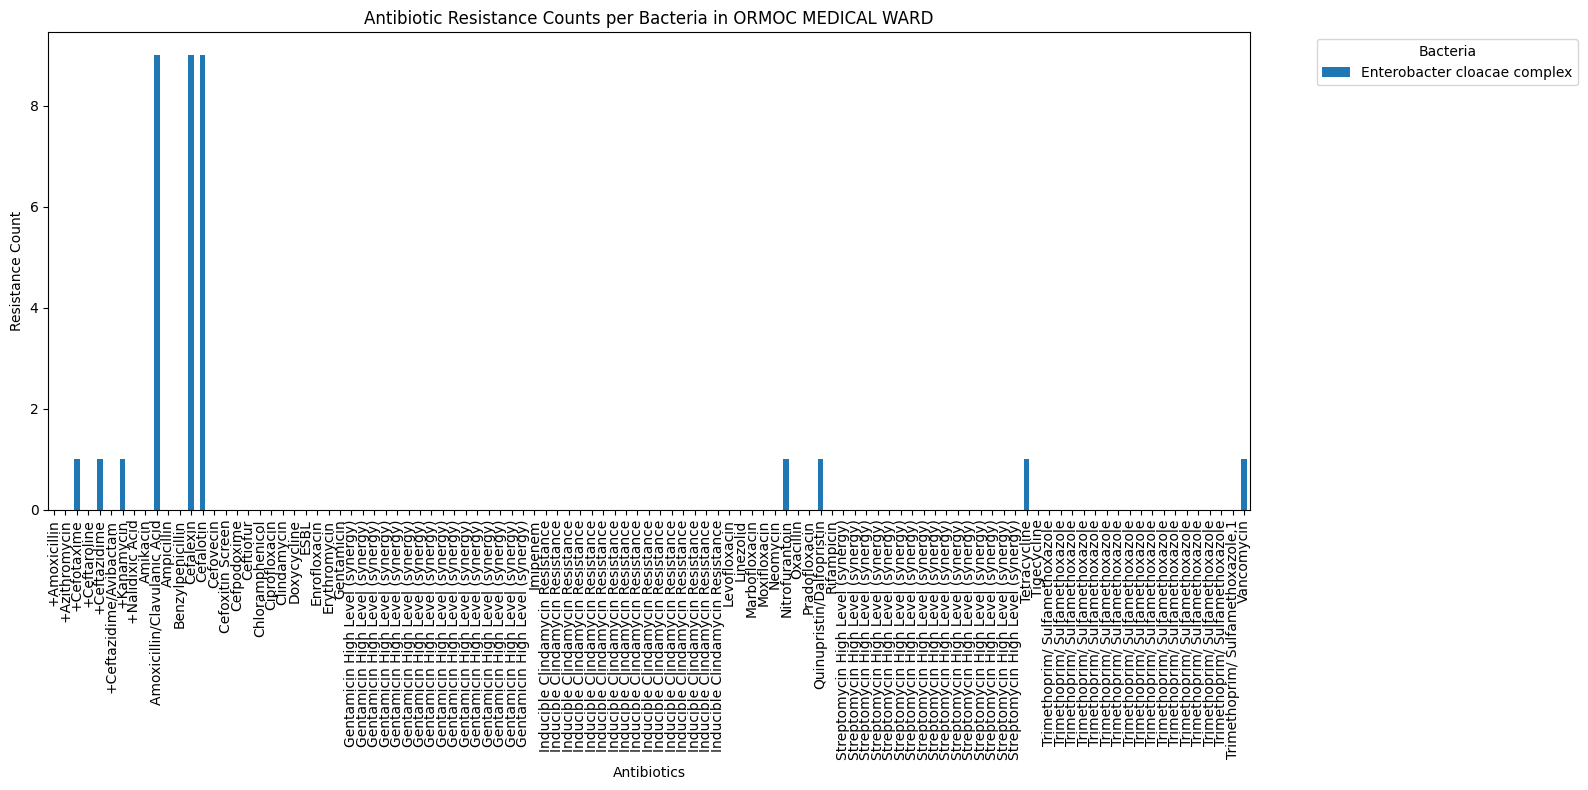

In [29]:
# Re-using the data previously loaded and cleaned for consistency
# Filter rows for "ORMOC MEDICAL WARD"
df_pedia = df[df['Origin'].str.contains("ORMOC MEDICAL WARD", case=False, na=False)]

# Identify antibiotic-related columns
non_antibiotic_cols = ['Sample_ID', 'Origin', 'Bacteria']
antibiotic_cols_all = [
    col for col in df_pedia.columns
    if col not in non_antibiotic_cols and not col.lower().startswith('unnamed') and not col.lower().startswith('nan')
]

# Encode resistance: R = 1, others = 0
encoded_antibiotics = df_pedia[antibiotic_cols_all].applymap(lambda x: 1 if x == 'R' else 0)

# Combine metadata with encoded resistance
df_encoded = pd.concat([df_pedia[non_antibiotic_cols].reset_index(drop=True), encoded_antibiotics.reset_index(drop=True)], axis=1)

# Count isolates per bacteria
bacteria_counts = df_encoded.groupby('Bacteria').agg({'Sample_ID': 'count'}).rename(columns={'Sample_ID': 'Isolates Count'})

# Sum resistance counts per antibiotic
resistance_summary_all = df_encoded.groupby('Bacteria')[antibiotic_cols_all].sum()

# Merge into final summary
ormocmedicalward_full_summary = pd.concat([bacteria_counts, resistance_summary_all], axis=1).reset_index()

# Plotting: Resistance count per bacteria (stacked bar chart)
plt.figure(figsize=(14, 8))
ormocmedicalward_full_summary.set_index('Bacteria')[antibiotic_cols_all].T.plot(kind='bar', stacked=True, figsize=(16, 8))
plt.title('Antibiotic Resistance Counts per Bacteria in ORMOC MEDICAL WARD')
plt.xlabel('Antibiotics')
plt.ylabel('Resistance Count')
plt.legend(title='Bacteria', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


ORMOC PEDIA WARD SUMMARY

In [30]:
import pandas as pd

# Standardize column names
df.columns = df.columns.str.strip().str.replace('\n', ' ').str.replace(r'\s+', ' ', regex=True)

# Filter hallway rows (adjust the filter based on actual content!)
df_hallway = df[df['Origin'].str.contains("ORMOC PEDIA WARD", case=False)]

# Identify antibiotic-related columns
non_antibiotic_cols = ['Sample_ID', 'Origin', 'Bacteria']
antibiotic_cols_all = [
    col for col in df_hallway.columns
    if col not in non_antibiotic_cols and not col.lower().startswith('unnamed') and not col.lower().startswith('nan')
]

# Encode resistance: R = 1, others = 0
encoded_antibiotics = df_hallway[antibiotic_cols_all].apply(lambda col: col.map(lambda x: 1 if x == 'R' else 0))

# Combine metadata with encoded resistance
df_encoded = pd.concat([df_hallway[non_antibiotic_cols].reset_index(drop=True), encoded_antibiotics.reset_index(drop=True)], axis=1)

# Count isolates per bacteria
bacteria_counts = df_encoded.groupby('Bacteria').agg({'Sample_ID': 'count'}).rename(columns={'Sample_ID': 'Isolates Count'})

# Sum resistance counts per antibiotic
resistance_summary_all = df_encoded.groupby('Bacteria')[antibiotic_cols_all].sum()

# Merge into final summary
ormocpediaward_full_summary = pd.concat([bacteria_counts, resistance_summary_all], axis=1).reset_index()

# Display or save
print(ormocpediaward_full_summary)

                          Bacteria  Isolates Count  +Amoxicillin  \
0  Acinetobacter baumannii complex               1             0   
1     Enterobacter cloacae complex               3             0   
2  Klebsiella pneumoniae ssp pneum               1             0   
3            Staphylococcus aureus               1             1   

   +Azithromycin  +Cefotaxime  +Ceftaroline  +Ceftazidime  \
0              0            0             0             0   
1              0            0             0             0   
2              0            0             0             0   
3              0            1             0             1   

   +Ceftazidime/Avibactam  +Kanamycin  +Nalidixic Acid  ...  \
0                       0           0                0  ...   
1                       0           0                0  ...   
2                       0           0                0  ...   
3                       0           0                0  ...   

   Trimethoprim/ Sulfamethoxazole  Tr

C:\Users\User\AppData\Local\Temp\ipykernel_3148\530427667.py:13: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  encoded_antibiotics = df_pedia[antibiotic_cols_all].applymap(lambda x: 1 if x == 'R' else 0)


<Figure size 1400x800 with 0 Axes>

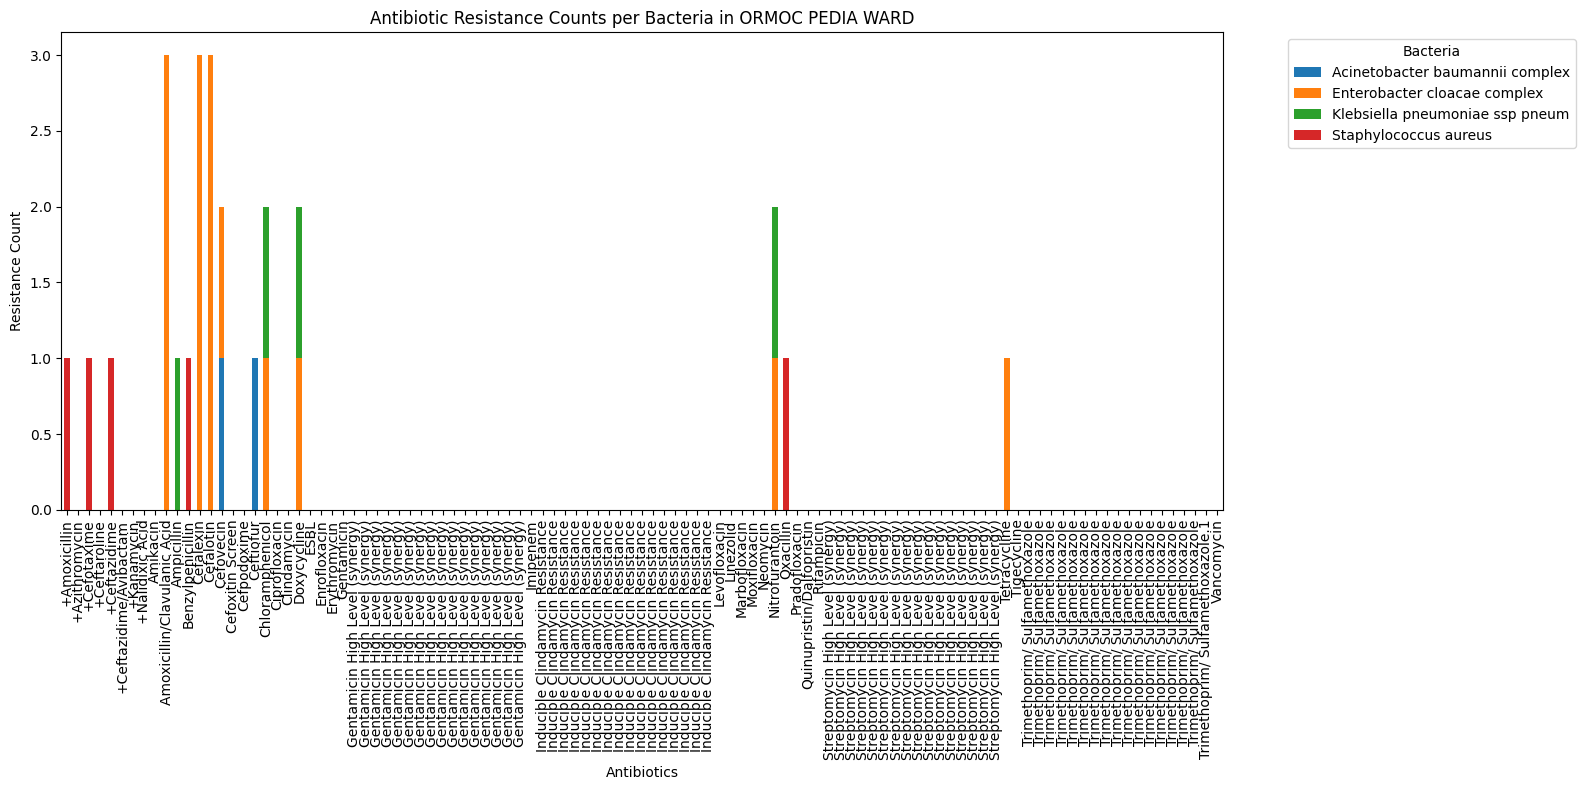

In [31]:
# Re-using the data previously loaded and cleaned for consistency
# Filter rows for "ORMOC PEDIA WARD"
df_pedia = df[df['Origin'].str.contains("ORMOC PEDIA WARD", case=False, na=False)]

# Identify antibiotic-related columns
non_antibiotic_cols = ['Sample_ID', 'Origin', 'Bacteria']
antibiotic_cols_all = [
    col for col in df_pedia.columns
    if col not in non_antibiotic_cols and not col.lower().startswith('unnamed') and not col.lower().startswith('nan')
]

# Encode resistance: R = 1, others = 0
encoded_antibiotics = df_pedia[antibiotic_cols_all].applymap(lambda x: 1 if x == 'R' else 0)

# Combine metadata with encoded resistance
df_encoded = pd.concat([df_pedia[non_antibiotic_cols].reset_index(drop=True), encoded_antibiotics.reset_index(drop=True)], axis=1)

# Count isolates per bacteria
bacteria_counts = df_encoded.groupby('Bacteria').agg({'Sample_ID': 'count'}).rename(columns={'Sample_ID': 'Isolates Count'})

# Sum resistance counts per antibiotic
resistance_summary_all = df_encoded.groupby('Bacteria')[antibiotic_cols_all].sum()

# Merge into final summary
ormocpediaward_full_summary = pd.concat([bacteria_counts, resistance_summary_all], axis=1).reset_index()

# Plotting: Resistance count per bacteria (stacked bar chart)
plt.figure(figsize=(14, 8))
ormocpediaward_full_summary.set_index('Bacteria')[antibiotic_cols_all].T.plot(kind='bar', stacked=True, figsize=(16, 8))
plt.title('Antibiotic Resistance Counts per Bacteria in ORMOC PEDIA WARD')
plt.xlabel('Antibiotics')
plt.ylabel('Resistance Count')
plt.legend(title='Bacteria', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


ORMOC SURGICAL WARD SUMMARY

In [33]:
import pandas as pd
# Standardize column names
df.columns = df.columns.str.strip().str.replace('\n', ' ').str.replace(r'\s+', ' ', regex=True)

# Filter hallway rows (adjust the filter based on actual content!)
df_hallway = df[df['Origin'].str.contains("ORMOC SURGICAL WARD", case=False)]

# Identify antibiotic-related columns
non_antibiotic_cols = ['Sample_ID', 'Origin', 'Bacteria']
antibiotic_cols_all = [
    col for col in df_hallway.columns
    if col not in non_antibiotic_cols and not col.lower().startswith('unnamed') and not col.lower().startswith('nan')
]

# Encode resistance: R = 1, others = 0
encoded_antibiotics = df_hallway[antibiotic_cols_all].apply(lambda col: col.map(lambda x: 1 if x == 'R' else 0))

# Combine metadata with encoded resistance
df_encoded = pd.concat([df_hallway[non_antibiotic_cols].reset_index(drop=True), encoded_antibiotics.reset_index(drop=True)], axis=1)

# Count isolates per bacteria
bacteria_counts = df_encoded.groupby('Bacteria').agg({'Sample_ID': 'count'}).rename(columns={'Sample_ID': 'Isolates Count'})

# Sum resistance counts per antibiotic
resistance_summary_all = df_encoded.groupby('Bacteria')[antibiotic_cols_all].sum()

# Merge into final summary
ormocsurgicalward_full_summary = pd.concat([bacteria_counts, resistance_summary_all], axis=1).reset_index()

# Display or save
print(ormocsurgicalward_full_summary)

                          Bacteria  Isolates Count  +Amoxicillin  \
0  Acinetobacter baumannii complex              14             0   
1     Enterobacter cloacae complex              54             0   
2            Staphylococcus aureus               6             6   

   +Azithromycin  +Cefotaxime  +Ceftaroline  +Ceftazidime  \
0              0            0             0             0   
1              0            0             0             0   
2              1            6             0             6   

   +Ceftazidime/Avibactam  +Kanamycin  +Nalidixic Acid  ...  \
0                       0           0                0  ...   
1                       0           0                0  ...   
2                       0           0                0  ...   

   Trimethoprim/ Sulfamethoxazole  Trimethoprim/ Sulfamethoxazole  \
0                               0                               0   
1                               0                              16   
2                     

C:\Users\User\AppData\Local\Temp\ipykernel_3148\2986905286.py:13: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  encoded_antibiotics = df_pedia[antibiotic_cols_all].applymap(lambda x: 1 if x == 'R' else 0)


<Figure size 1400x800 with 0 Axes>

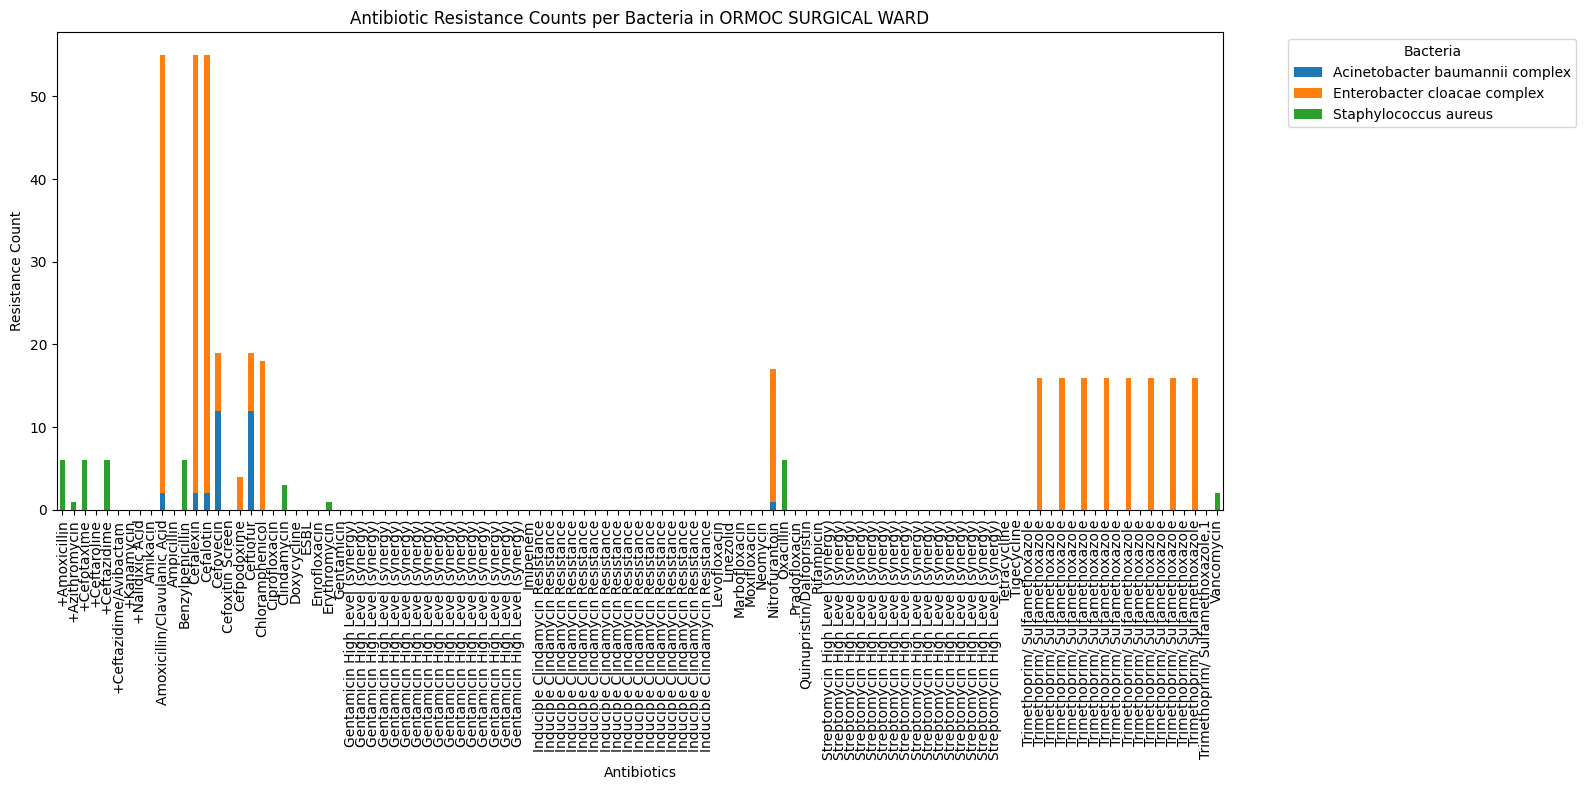

In [34]:
# Re-using the data previously loaded and cleaned for consistency
# Filter rows for "ORMOC SURGICAL WARD"
df_pedia = df[df['Origin'].str.contains("ORMOC SURGICAL WARD", case=False, na=False)]

# Identify antibiotic-related columns
non_antibiotic_cols = ['Sample_ID', 'Origin', 'Bacteria']
antibiotic_cols_all = [
    col for col in df_pedia.columns
    if col not in non_antibiotic_cols and not col.lower().startswith('unnamed') and not col.lower().startswith('nan')
]

# Encode resistance: R = 1, others = 0
encoded_antibiotics = df_pedia[antibiotic_cols_all].applymap(lambda x: 1 if x == 'R' else 0)

# Combine metadata with encoded resistance
df_encoded = pd.concat([df_pedia[non_antibiotic_cols].reset_index(drop=True), encoded_antibiotics.reset_index(drop=True)], axis=1)

# Count isolates per bacteria
bacteria_counts = df_encoded.groupby('Bacteria').agg({'Sample_ID': 'count'}).rename(columns={'Sample_ID': 'Isolates Count'})

# Sum resistance counts per antibiotic
resistance_summary_all = df_encoded.groupby('Bacteria')[antibiotic_cols_all].sum()

# Merge into final summary
ormocsurgicalward_full_summary = pd.concat([bacteria_counts, resistance_summary_all], axis=1).reset_index()

# Plotting: Resistance count per bacteria (stacked bar chart)
plt.figure(figsize=(14, 8))
ormocsurgicalward_full_summary.set_index('Bacteria')[antibiotic_cols_all].T.plot(kind='bar', stacked=True, figsize=(16, 8))
plt.title('Antibiotic Resistance Counts per Bacteria in ORMOC SURGICAL WARD')
plt.xlabel('Antibiotics')
plt.ylabel('Resistance Count')
plt.legend(title='Bacteria', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


ORMOC CR SUMMARY

In [35]:
import pandas as pd

# Standardize column names
df.columns = df.columns.str.strip().str.replace('\n', ' ').str.replace(r'\s+', ' ', regex=True)

# Filter hallway rows (adjust the filter based on actual content!)
df_hallway = df[df['Origin'].str.contains("ORMOC CR", case=False)]

# Identify antibiotic-related columns
non_antibiotic_cols = ['Sample_ID', 'Origin', 'Bacteria']
antibiotic_cols_all = [
    col for col in df_hallway.columns
    if col not in non_antibiotic_cols and not col.lower().startswith('unnamed') and not col.lower().startswith('nan')
]

# Encode resistance: R = 1, others = 0
encoded_antibiotics = df_hallway[antibiotic_cols_all].apply(lambda col: col.map(lambda x: 1 if x == 'R' else 0))

# Combine metadata with encoded resistance
df_encoded = pd.concat([df_hallway[non_antibiotic_cols].reset_index(drop=True), encoded_antibiotics.reset_index(drop=True)], axis=1)

# Count isolates per bacteria
bacteria_counts = df_encoded.groupby('Bacteria').agg({'Sample_ID': 'count'}).rename(columns={'Sample_ID': 'Isolates Count'})

# Sum resistance counts per antibiotic
resistance_summary_all = df_encoded.groupby('Bacteria')[antibiotic_cols_all].sum()

# Merge into final summary
ormoccr_full_summary = pd.concat([bacteria_counts, resistance_summary_all], axis=1).reset_index()

# Display or save
print(ormoccr_full_summary)

               Bacteria  Isolates Count  +Amoxicillin  +Azithromycin  \
0  Enterococcus faecium               2             2              0   

   +Cefotaxime  +Ceftaroline  +Ceftazidime  +Ceftazidime/Avibactam  \
0            2             0             2                       0   

   +Kanamycin  +Nalidixic Acid  ...  Trimethoprim/ Sulfamethoxazole  \
0           2                0  ...                               0   

   Trimethoprim/ Sulfamethoxazole  Trimethoprim/ Sulfamethoxazole  \
0                               0                               0   

   Trimethoprim/ Sulfamethoxazole  Trimethoprim/ Sulfamethoxazole  \
0                               0                               0   

   Trimethoprim/ Sulfamethoxazole  Trimethoprim/ Sulfamethoxazole  \
0                               0                               0   

   Trimethoprim/ Sulfamethoxazole  Trimethoprim/ Sulfamethoxazole.1  \
0                               0                                 0   

   Vancomyc

C:\Users\User\AppData\Local\Temp\ipykernel_3148\1190179039.py:13: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  encoded_antibiotics = df_pedia[antibiotic_cols_all].applymap(lambda x: 1 if x == 'R' else 0)


<Figure size 1400x800 with 0 Axes>

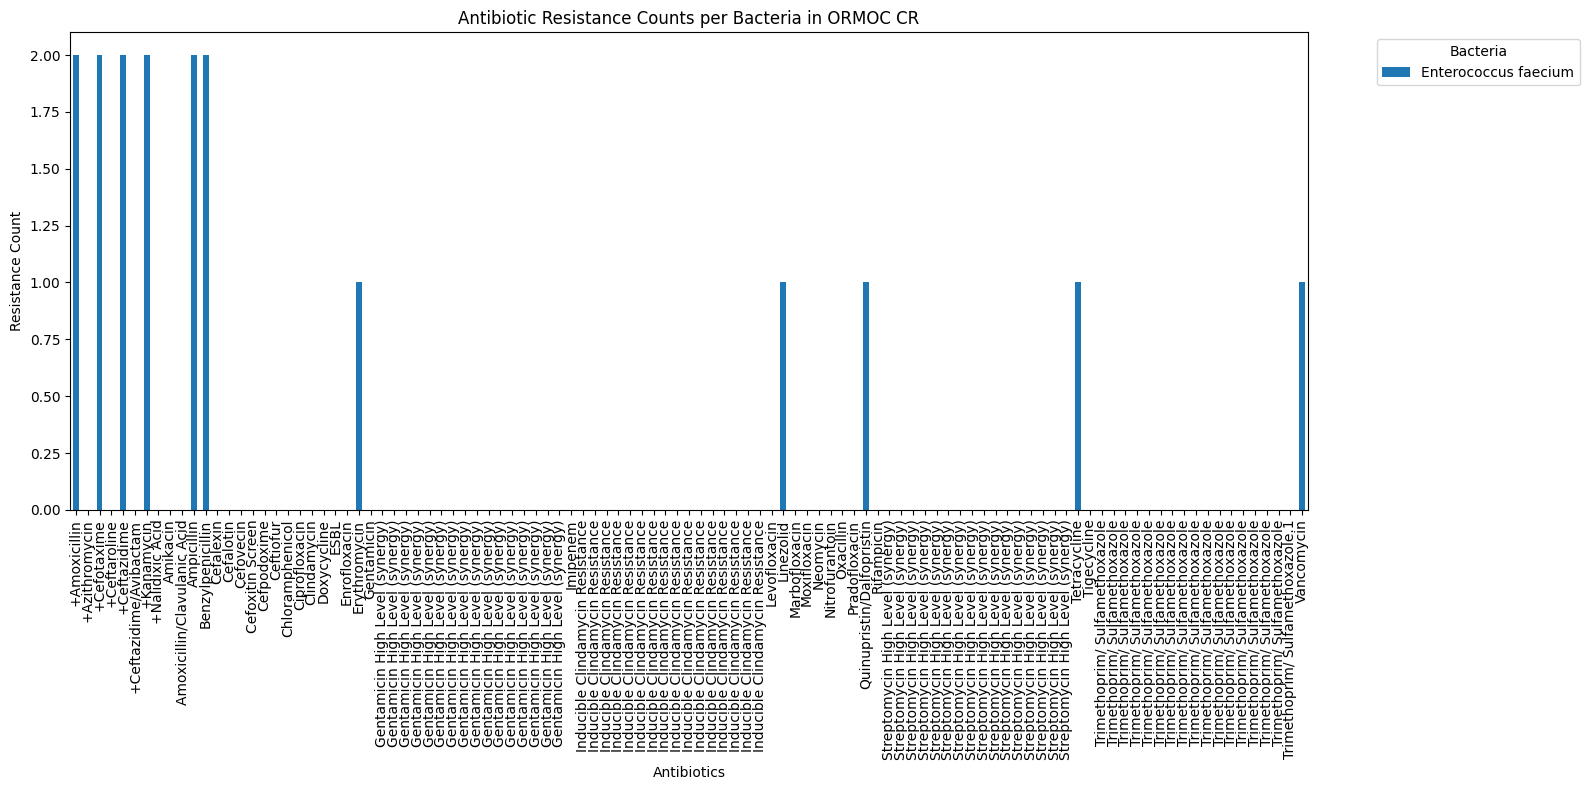

In [36]:
# Re-using the data previously loaded and cleaned for consistency
# Filter rows for "ORMOC CR"
df_pedia = df[df['Origin'].str.contains("ORMOC CR", case=False, na=False)]

# Identify antibiotic-related columns
non_antibiotic_cols = ['Sample_ID', 'Origin', 'Bacteria']
antibiotic_cols_all = [
    col for col in df_pedia.columns
    if col not in non_antibiotic_cols and not col.lower().startswith('unnamed') and not col.lower().startswith('nan')
]

# Encode resistance: R = 1, others = 0
encoded_antibiotics = df_pedia[antibiotic_cols_all].applymap(lambda x: 1 if x == 'R' else 0)

# Combine metadata with encoded resistance
df_encoded = pd.concat([df_pedia[non_antibiotic_cols].reset_index(drop=True), encoded_antibiotics.reset_index(drop=True)], axis=1)

# Count isolates per bacteria
bacteria_counts = df_encoded.groupby('Bacteria').agg({'Sample_ID': 'count'}).rename(columns={'Sample_ID': 'Isolates Count'})

# Sum resistance counts per antibiotic
resistance_summary_all = df_encoded.groupby('Bacteria')[antibiotic_cols_all].sum()

# Merge into final summary
ormoccr_full_summary = pd.concat([bacteria_counts, resistance_summary_all], axis=1).reset_index()

# Plotting: Resistance count per bacteria (stacked bar chart)
plt.figure(figsize=(14, 8))
ormoccr_full_summary.set_index('Bacteria')[antibiotic_cols_all].T.plot(kind='bar', stacked=True, figsize=(16, 8))
plt.title('Antibiotic Resistance Counts per Bacteria in ORMOC CR')
plt.xlabel('Antibiotics')
plt.ylabel('Resistance Count')
plt.legend(title='Bacteria', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


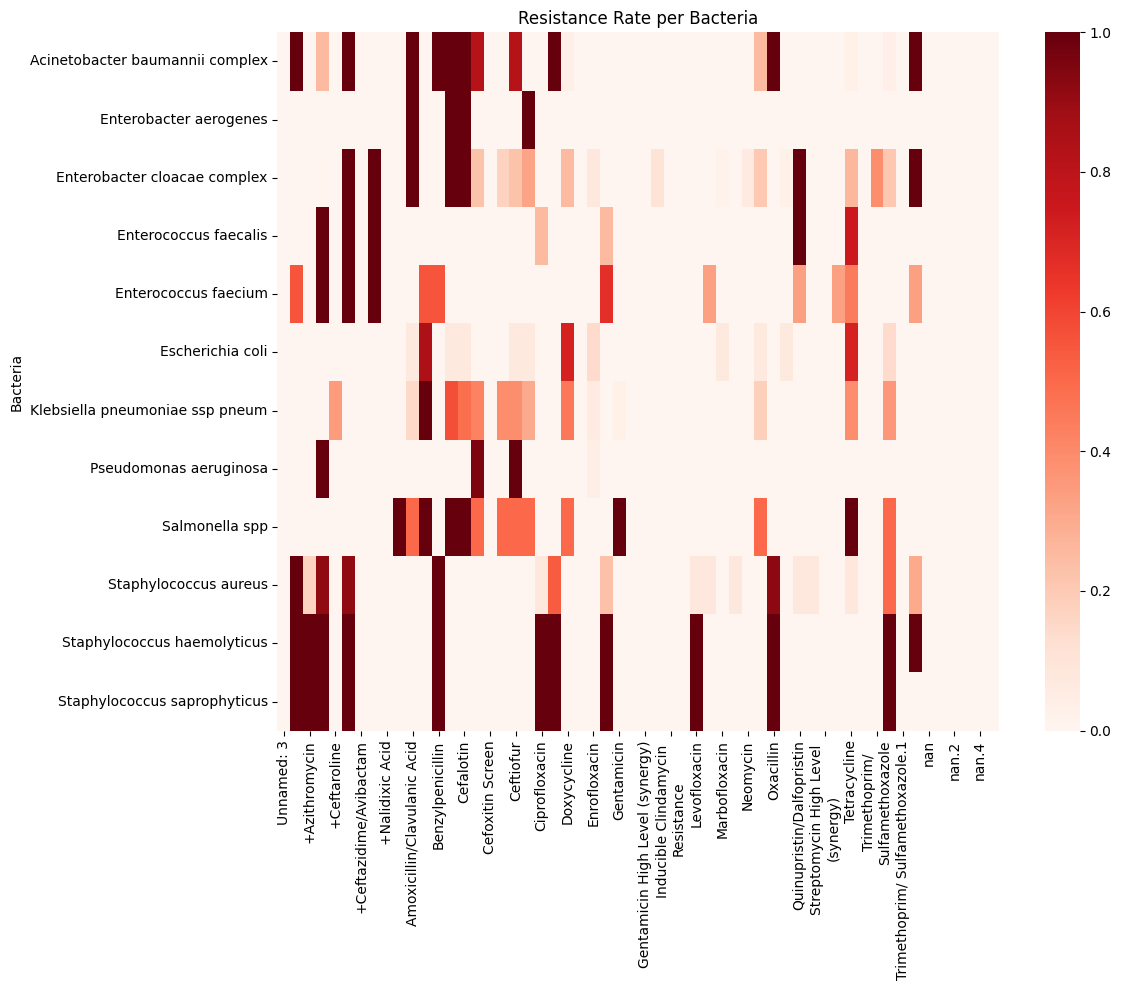

In [38]:
df = pd.read_excel(r'C:\Users\User\Documents\SPVM 2025\AMR_merged_all_samples_ordered.xlsx')

import seaborn as sns
import matplotlib.pyplot as plt

# Select resistance columns
resistance_cols = df.columns[3:]

# Compute resistance rates per bacteria
pattern = df.groupby('Bacteria')[resistance_cols].apply(lambda x: (x == 'R').sum() / x.notna().sum())

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(pattern.fillna(0), cmap="Reds")
plt.title("Resistance Rate per Bacteria")
plt.tight_layout()
plt.show()

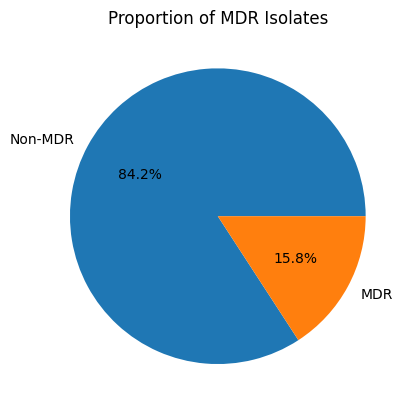

In [40]:
# Count how many antibiotics each isolate is resistant to
df['resistant_count'] = (df[resistance_cols] == 'R').sum(axis=1)
df['MDR'] = df['resistant_count'] >= 3

# Plot
df['MDR'].value_counts().plot(kind='pie', labels=['Non-MDR', 'MDR'], autopct='%1.1f%%')
plt.title("Proportion of MDR Isolates")
plt.ylabel('')
plt.show()

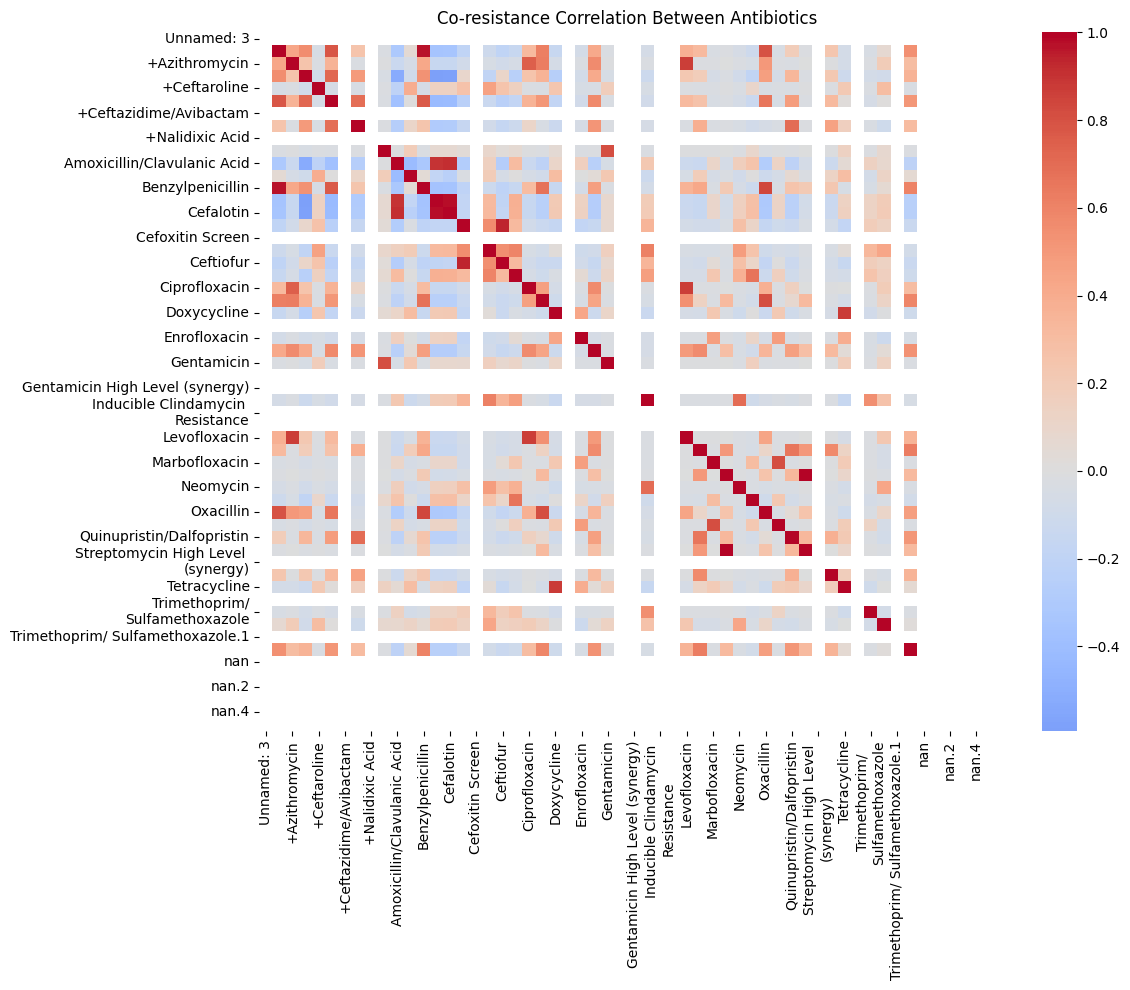

In [41]:
import numpy as np

# Binary encoding: R=1, others=0
binary_df = (df[resistance_cols] == 'R').astype(int)

# Correlation matrix
corr_matrix = binary_df.corr()

# Visualize
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0)
plt.title("Co-resistance Correlation Between Antibiotics")
plt.tight_layout()
plt.show()

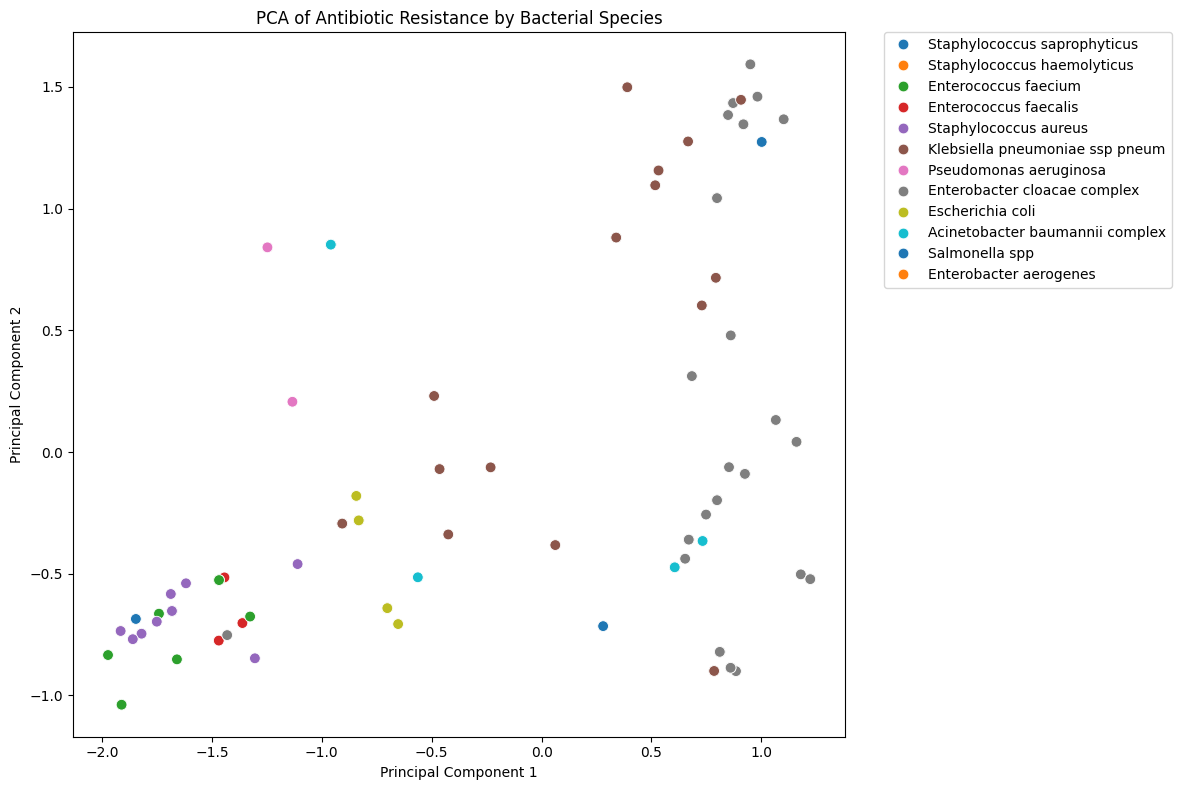

In [42]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare binary matrix
X = binary_df.fillna(0)

# PCA
pca = PCA(n_components=2)
components = pca.fit_transform(X)
df['PC1'], df['PC2'] = components[:, 0], components[:, 1]

# Plot with legend
plt.figure(figsize=(12, 8))
scatter = sns.scatterplot(data=df, x='PC1', y='PC2', hue='Bacteria', palette='tab10', legend='full', s=60)

# Move legend outside plot if too many classes
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.title("PCA of Antibiotic Resistance by Bacterial Species")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.tight_layout()
plt.show()

=== Decision Tree Report ===
                     precision    recall  f1-score   support

    AMPC PEDIA WARD       1.00      0.33      0.50         9
  APMC GENERAL WARD       0.40      0.33      0.36         6
       APMC HALLWAY       0.44      0.44      0.44         9
   ORMOC GENERAL CR       0.35      0.88      0.50         8
   ORMOC GENERAL ER       0.00      0.00      0.00         5
      ORMOC HALLWAY       0.00      0.00      0.00         1
 ORMOC MEDICAL WARD       0.00      0.00      0.00         2
   ORMOC PEDIA WARD       0.00      0.00      0.00         1
ORMOC SURGICAL WARD       0.58      0.73      0.65        15

           accuracy                           0.48        56
          macro avg       0.31      0.30      0.27        56
       weighted avg       0.48      0.48      0.44        56

Accuracy: 0.48214285714285715

=== Logistic Regression Report ===
                     precision    recall  f1-score   support

    AMPC PEDIA WARD       0.75      0.33      0

C:\Users\User\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\User\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\User\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

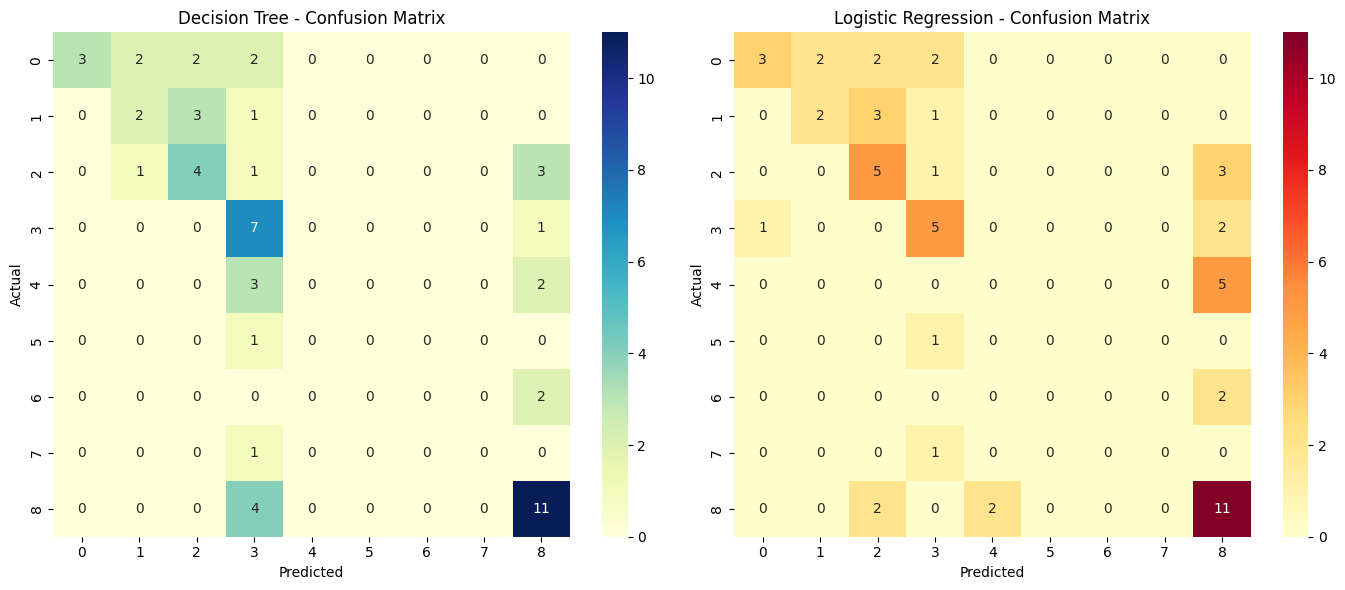

C:\Users\User\AppData\Local\Temp\ipykernel_3148\2282737735.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette='viridis')


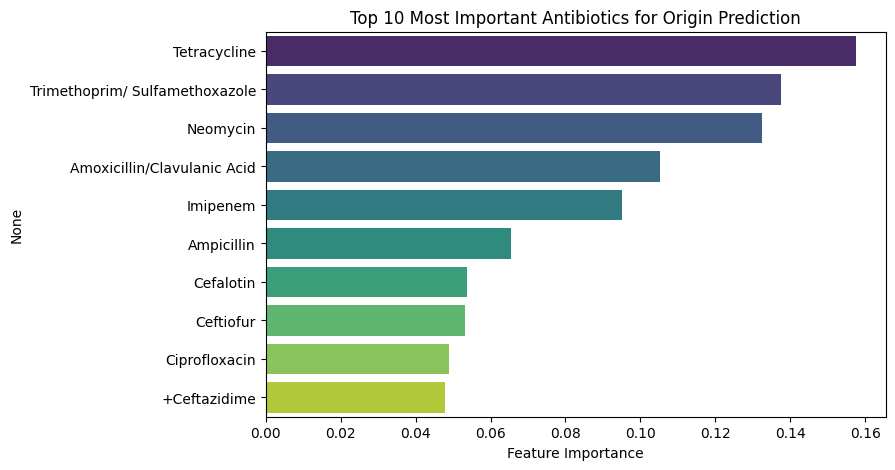

In [44]:
# --- IMPORT LIBRARIES ---
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# --- LOAD DATA ---
df = pd.read_excel(r'C:\Users\User\Documents\SPVM 2025\AMR_merged_all_samples_ordered.xlsx')

# --- SELECT FEATURES AND TARGET ---
# Assuming resistance columns contain antibiotic results (e.g., 'R', 'S', 'I')
# and there’s a column like 'Origin' for location
resistance_cols = [col for col in df.columns if col not in ['Origin', 'Sample_ID', 'Bacteria', 'Location', 'Source']]

# Encode resistance values: Resistant (R)=1, others=0
X = (df[resistance_cols] == 'R').astype(int)

# Target variable (origin of bacteria)
y = df['Origin']

# --- TRAIN-TEST SPLIT ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# --- DECISION TREE CLASSIFIER ---
dt = DecisionTreeClassifier(random_state=42, max_depth=5)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

# --- LOGISTIC REGRESSION ---
log_reg = LogisticRegression(max_iter=500)
log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)

# --- EVALUATION ---
print("=== Decision Tree Report ===")
print(classification_report(y_test, y_pred_dt))
print("Accuracy:", accuracy_score(y_test, y_pred_dt))

print("\n=== Logistic Regression Report ===")
print(classification_report(y_test, y_pred_lr))
print("Accuracy:", accuracy_score(y_test, y_pred_lr))

# --- CONFUSION MATRIX VISUALIZATION ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt='d', cmap='YlGnBu', ax=axes[0])
axes[0].set_title("Decision Tree - Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='YlOrRd', ax=axes[1])
axes[1].set_title("Logistic Regression - Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

# --- FEATURE IMPORTANCE FROM DECISION TREE ---
importances = pd.Series(dt.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)[:10]

plt.figure(figsize=(8,5))
sns.barplot(x=importances.values, y=importances.index, palette='viridis')
plt.title("Top 10 Most Important Antibiotics for Origin Prediction")
plt.xlabel("Feature Importance")
plt.show()


=== Decision Tree Predictions ===
                 Actual            Predicted
0          APMC HALLWAY         APMC HALLWAY
1          APMC HALLWAY  ORMOC SURGICAL WARD
2   ORMOC SURGICAL WARD  ORMOC SURGICAL WARD
3       AMPC PEDIA WARD     ORMOC GENERAL CR
4       AMPC PEDIA WARD    APMC GENERAL WARD
5          APMC HALLWAY     ORMOC GENERAL CR
6     APMC GENERAL WARD         APMC HALLWAY
7    ORMOC MEDICAL WARD  ORMOC SURGICAL WARD
8          APMC HALLWAY         APMC HALLWAY
9      ORMOC GENERAL ER     ORMOC GENERAL CR
10      AMPC PEDIA WARD    APMC GENERAL WARD
11         APMC HALLWAY  ORMOC SURGICAL WARD
12     ORMOC PEDIA WARD     ORMOC GENERAL CR
13     ORMOC GENERAL CR     ORMOC GENERAL CR
14     ORMOC GENERAL CR     ORMOC GENERAL CR

Decision Tree Accuracy: 0.482

=== Logistic Regression Predictions ===
                 Actual            Predicted
0          APMC HALLWAY         APMC HALLWAY
1          APMC HALLWAY  ORMOC SURGICAL WARD
2   ORMOC SURGICAL WARD  ORMOC SURGICAL

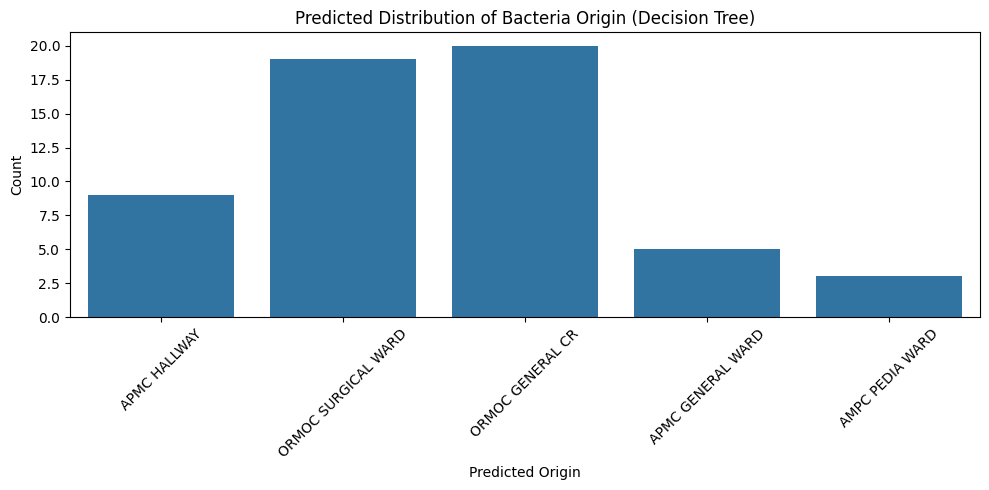

In [45]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# --- IDENTIFY COLUMNS ---
# Replace 'Origin' with the actual column name for sample location if different
resistance_cols = [col for col in df.columns if col not in ['Origin', 'Sample_ID', 'Bacteria', 'Location', 'Source']]

# --- ENCODE RESISTANCE VALUES ---
X = (df[resistance_cols] == 'R').astype(int)
y = df['Origin']  # change if your column is named 'Location' or similar

# --- TRAIN/TEST SPLIT ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# --- DECISION TREE ---
dt = DecisionTreeClassifier(random_state=42, max_depth=5)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

# --- LOGISTIC REGRESSION ---
lr = LogisticRegression(max_iter=500)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

# --- SHOW RESULTS ---
print("=== Decision Tree Predictions ===")
print(pd.DataFrame({'Actual': y_test.values, 'Predicted': dt_pred}).head(15))
print("\nDecision Tree Accuracy:", round(accuracy_score(y_test, dt_pred), 3))

print("\n=== Logistic Regression Predictions ===")
print(pd.DataFrame({'Actual': y_test.values, 'Predicted': lr_pred}).head(15))
print("\nLogistic Regression Accuracy:", round(accuracy_score(y_test, lr_pred), 3))

# --- OPTIONAL: Simple Visual Comparison ---
plt.figure(figsize=(10,5))
sns.countplot(x=dt_pred)
plt.title("Predicted Distribution of Bacteria Origin (Decision Tree)")
plt.xlabel("Predicted Origin")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Decision Tree R² Score: 0.389


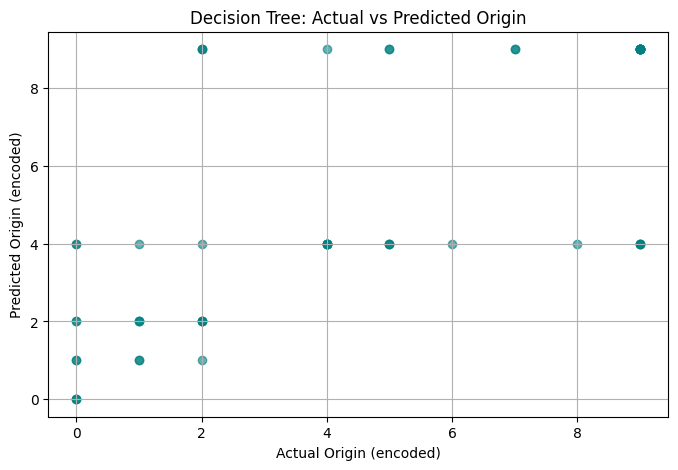

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score

# --- Load dataset ---
df = pd.read_excel(r'C:\Users\User\Documents\SPVM 2025\AMR_merged_all_samples_ordered.xlsx')
# --- Identify columns ---
resistance_cols = [col for col in df.columns if col not in ['Origin', 'Sample_ID', 'Bacteria', 'Location', 'Source']]

# --- Encode resistance (R=1, others=0) ---
X = (df[resistance_cols] == 'R').astype(int)

# --- Encode origin labels numerically ---
le = LabelEncoder()
y = le.fit_transform(df['Origin'])  # e.g., Hallway=0, Pedia Ward=1, etc.

# --- Train/test split ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# --- Decision Tree ---
dt = DecisionTreeClassifier(random_state=42, max_depth=5)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

# --- R² score ---
r2_dt = r2_score(y_test, y_pred_dt)
print("Decision Tree R² Score:", round(r2_dt, 3))

# --- Plot actual vs predicted ---
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred_dt, alpha=0.6, color='teal')
plt.title("Decision Tree: Actual vs Predicted Origin")
plt.xlabel("Actual Origin (encoded)")
plt.ylabel("Predicted Origin (encoded)")
plt.grid(True)
plt.show()


In [47]:
# === CORRELATION ANALYSIS ===
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_excel("AMR_merged_all_samples_ordered.xlsx")

# Identify resistance columns (exclude metadata)
resistance_cols = [col for col in df.columns if col not in ['Origin', 'Sample_ID', 'Bacteria', 'Location', 'Source']]

# Binary encode: R=1, others=0
binary_df = (df[resistance_cols] == 'R').astype(int)

# Compute Pearson correlation
corr_matrix = binary_df.corr()

# Visualize co-resistance correlation
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Co-resistance Correlation Between Antibiotics")
plt.tight_layout()
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: 'AMR_merged_all_samples_ordered.xlsx'